# Makine Öğrenmesi - Ara Sınav Ödevi
# Okan ULUĞLU

**Veri Seti:** Wine Classification (scikit-learn)

Wine veri seti üzerinde klasik ML modelleri, PCA/LDA boyut indirgeme ve SHAP açıklanabilirlik analizi.

In [1]:
# Colab için gerekli kurulumlar
try:
    import xgboost, shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'shap', '-q'])

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)
from scipy import stats
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 11

---
## 1. Veri Setinin Yüklenmesi

In [3]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

print(f"Boyut: {X.shape[0]} satir, {X.shape[1]} ozellik")
print(f"Siniflar: {list(wine.target_names)}")
print(f"\nSinif dagilimi:\n{y.value_counts().sort_index()}")

X.head()

Boyut: 178 satir, 13 ozellik
Siniflar: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Sinif dagilimi:
target
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


---
## 2. Veri Kalite Kontrolleri

### 2.1 Eksik Değer Analizi

In [4]:
missing = X.isnull().sum()
print(f"Toplam eksik deger: {missing.sum()}")

if missing.sum() > 0:
    X = X.fillna(X.mean())
    print("Eksik degerler ortalama ile dolduruldu.")
else:
    print("Eksik deger yok, herhangi bir doldurma islemi gerekmedi.")

Toplam eksik deger: 0
Eksik deger yok, herhangi bir doldurma islemi gerekmedi.


### 2.2 Aykırı Değer Analizi

In [5]:
# IQR yontemi
Q1  = X.quantile(0.25)
Q3  = X.quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

outlier_mask   = (X < alt_sinir) | (X > ust_sinir)
outlier_sayisi = outlier_mask.sum().sort_values(ascending=False)

print("IQR ile aykiri deger sayilari:")
print(outlier_sayisi[outlier_sayisi > 0])
print(f"\nToplam: {outlier_mask.sum().sum()} aykiri deger")

IQR ile aykiri deger sayilari:
magnesium            4
alcalinity_of_ash    4
color_intensity      4
malic_acid           3
ash                  3
proanthocyanins      2
hue                  1
dtype: int64

Toplam: 21 aykiri deger


In [6]:
# Z-score yontemi
z_scores = pd.DataFrame(np.abs(stats.zscore(X)), columns=X.columns)
z_outlier = (z_scores > 3).sum()

print("Z-Score (|z| > 3) ile aykiri degerler:")
print(z_outlier[z_outlier > 0])

Z-Score (|z| > 3) ile aykiri degerler:
malic_acid           1
ash                  3
alcalinity_of_ash    1
magnesium            2
flavanoids           1
proanthocyanins      1
color_intensity      1
hue                  1
dtype: int64


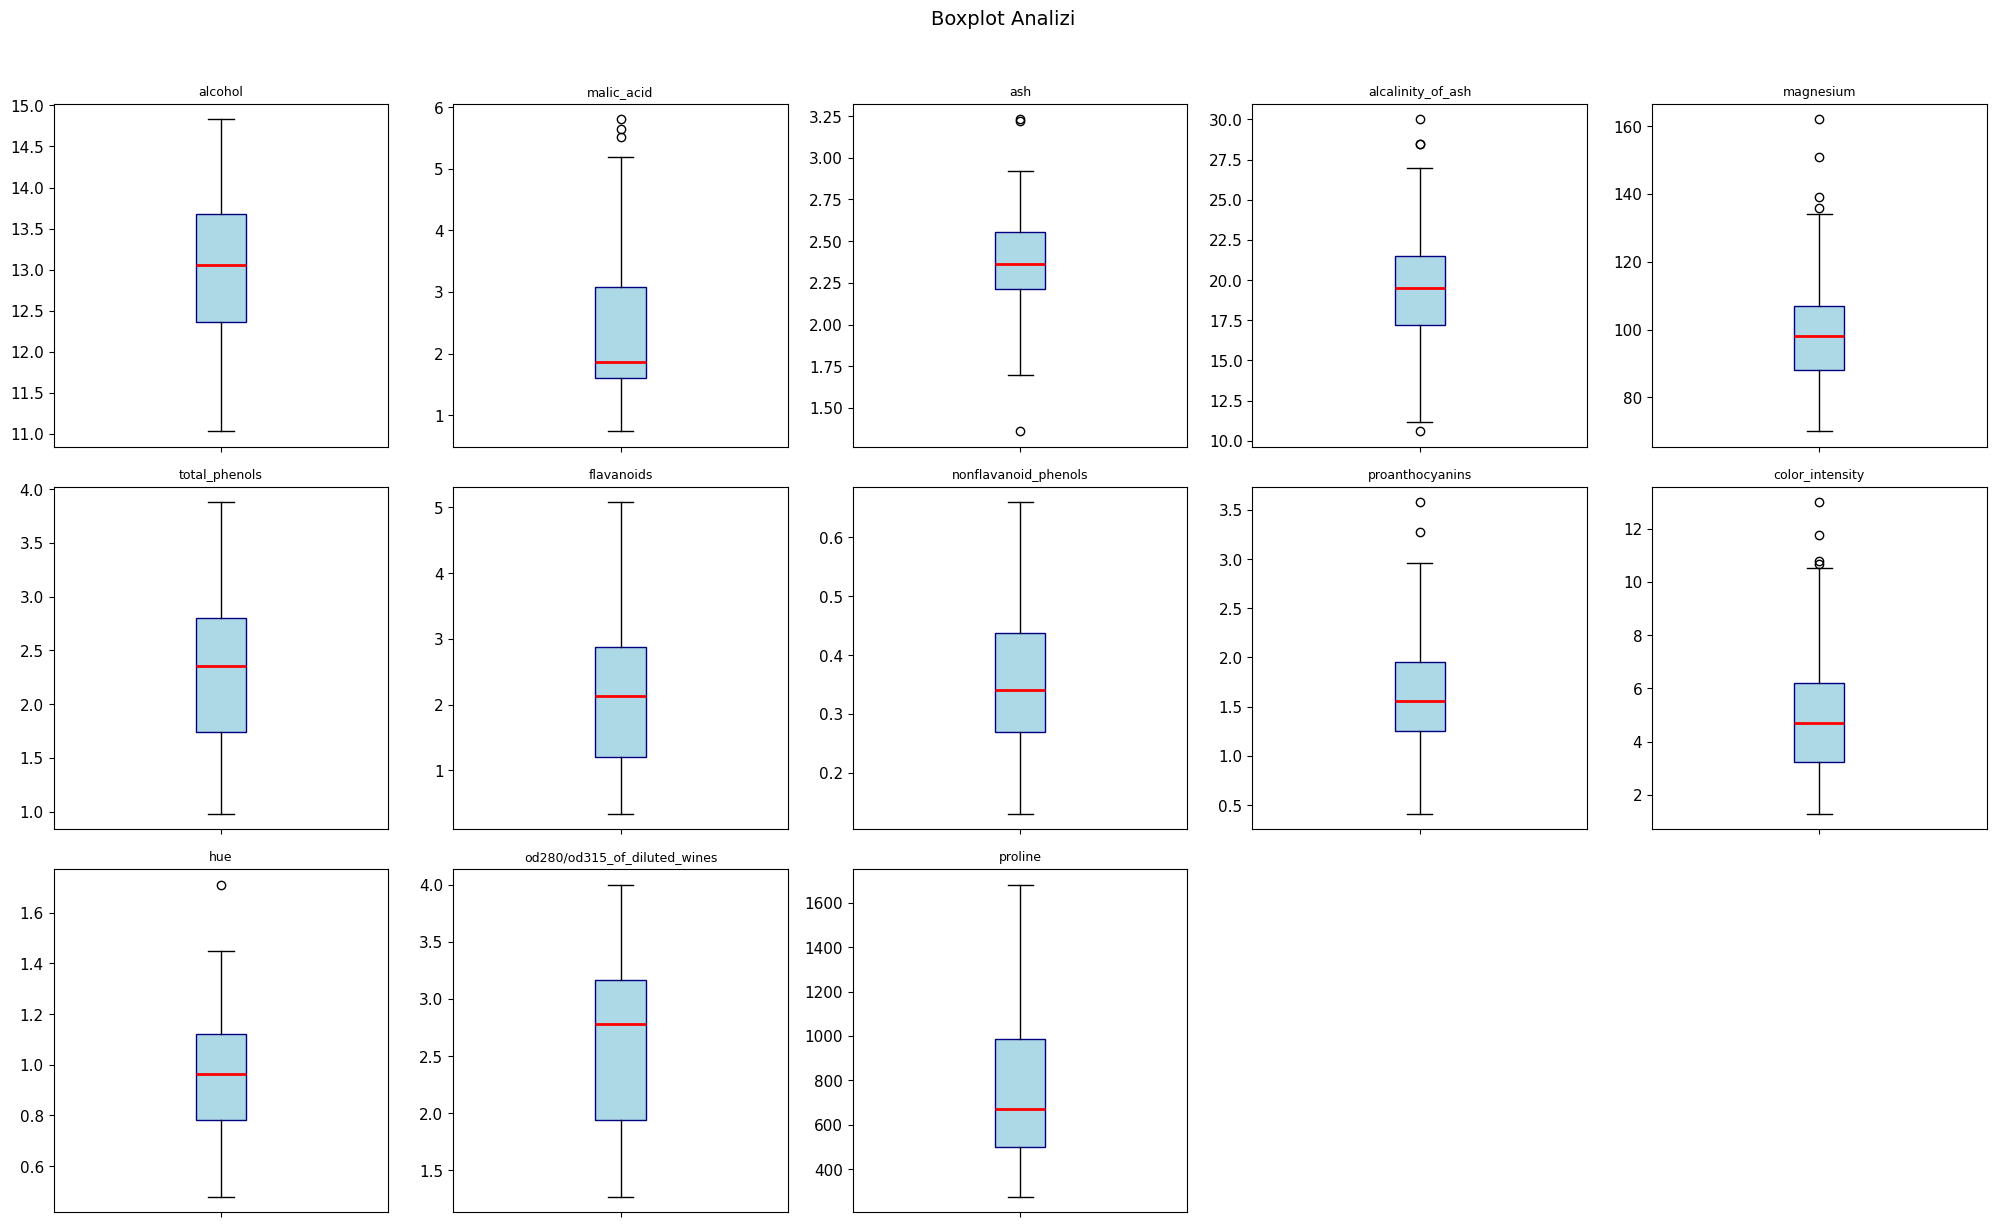

In [7]:
# Boxplot - tum ozellikler
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes      = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].boxplot(X[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', labelbottom=False)

for i in range(len(X.columns), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Boxplot Analizi', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# magnesium, proline, color_intensity gibi özelliklerde belirgin aykırı değerler görülüyor.
# StandardScaler bu etkiyi azaltacak.

### 2.3 Veri Tipi İncelemesi

In [8]:
# Sayisal / kategorik degisken sayilari
print(f"Sayisal degisken  : {X.select_dtypes(include=[np.number]).shape[1]}")
print(f"Kategorik degisken: {X.select_dtypes(include=['object','category']).shape[1]}")
print()

# Her sutunun dtype bilgisi (odev gereksinimi)
print("Her ozelligin veri tipi (dtype):")
print(X.dtypes.to_string())
print()

# Dagilim ozeti: carpiklik ve basiklik
carpiklik = X.skew().round(3)
basiklik  = X.kurtosis().round(3)
dagilim_df = pd.DataFrame({'Skewness': carpiklik, 'Kurtosis': basiklik})
print("Carpiklik (Skewness) ve Basiklik (Kurtosis):")
print(dagilim_df.to_string())
print()
print("Yorum: Skewness > 1 veya < -1 ise dagilis belirgin sekilde carpik.")
print("proline (skewness ~1.14) ve color_intensity pozitif carpik; malic_acid da sagdan uzun kuyruklu.")
print("StandardScaler bu etkileri ortalama 0, std 1 yaparak normallestirir.")

Sayisal degisken  : 13
Kategorik degisken: 0

Her ozelligin veri tipi (dtype):
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64

Carpiklik (Skewness) ve Basiklik (Kurtosis):
                              Skewness  Kurtosis
alcohol                         -0.051    -0.852
malic_acid                       1.040     0.299
ash                             -0.177     1.144
alcalinity_of_ash                0.213     0.488
magnesium                        1.098     2.105
total_phenols                    0.087    -0.836
flavanoids  

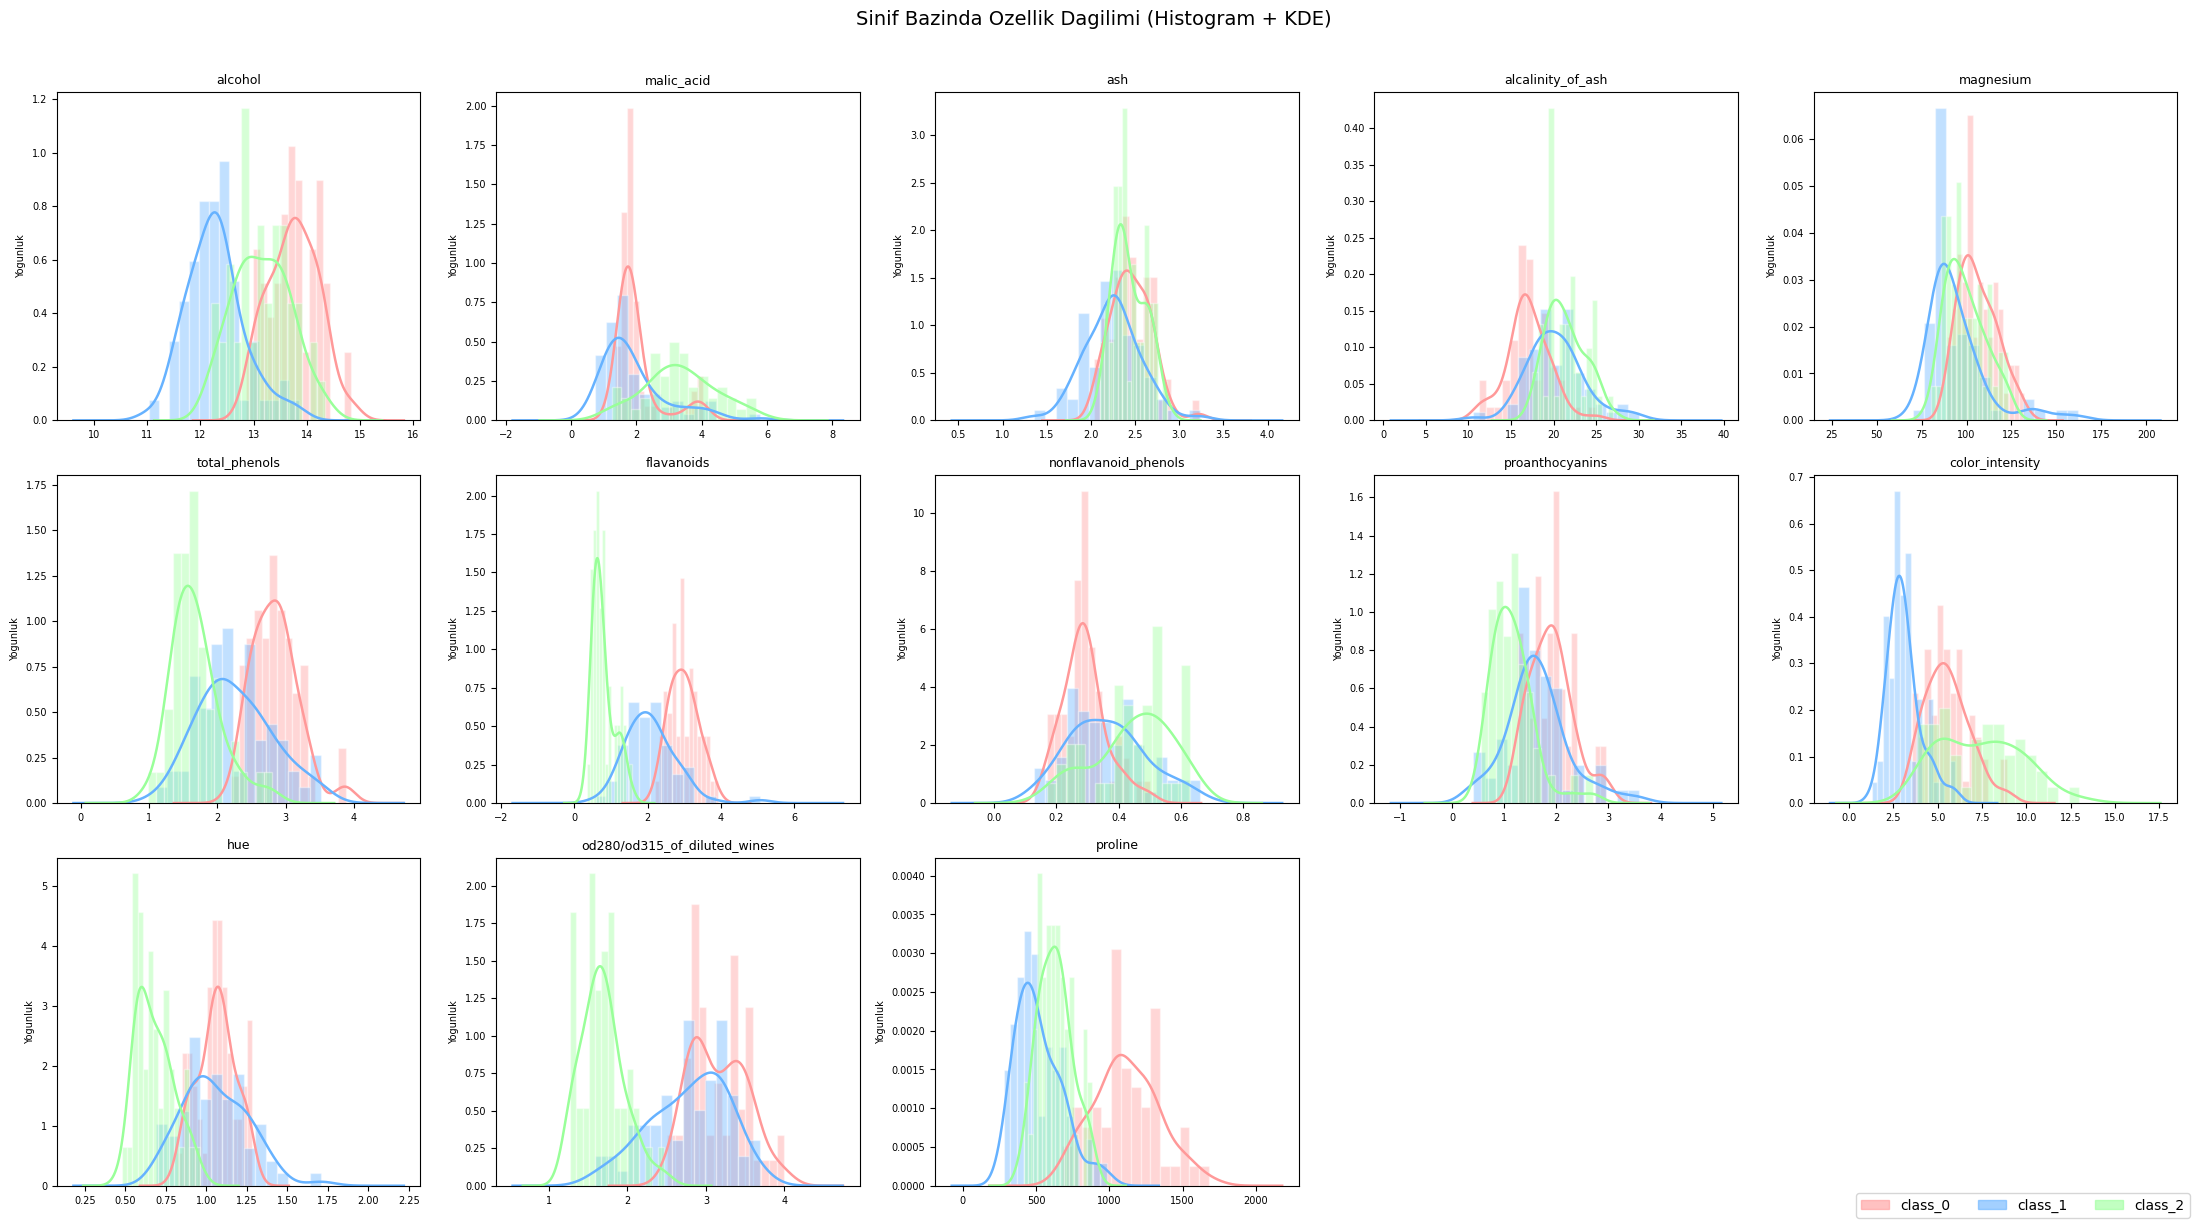

In [9]:
# ---- Dagilim Grafigi (Histogram + KDE) ----
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()
renkler_h = ['#FF9999', '#66B2FF', '#99FF99']

for i, col in enumerate(X.columns):
    for c in range(3):
        subset = X[y == c][col]
        axes[i].hist(subset, bins=15, alpha=0.4, color=renkler_h[c],
                     edgecolor='white', density=True, label=wine.target_names[c])
        subset.plot.kde(ax=axes[i], color=renkler_h[c], linewidth=1.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Yogunluk', fontsize=7)
    axes[i].tick_params(labelsize=7)

for i in range(len(X.columns), len(axes)):
    fig.delaxes(axes[i])

handles = [plt.Rectangle((0,0),1,1, color=renkler_h[c], alpha=0.6) for c in range(3)]
fig.legend(handles, wine.target_names, loc='lower right', ncol=3, fontsize=10)
plt.suptitle('Sinif Bazinda Ozellik Dagilimi (Histogram + KDE)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Yorum:
# flavanoids, proline ve alcohol siniflar arasinda belirgin farkli dagilimlara sahip.
# Bu ozellikler yuksek sinif ayirt ediciligine sahiptir (EDA gozlemleriyle tutarli).
# Malic_acid ve color_intensity pozitif carpik dagilis sergiliyor.


---
## 3. Keşifsel Veri Analizi (EDA)

### 3.1 İstatistiksel Özellikler

In [10]:
istatistik = pd.DataFrame({
    'Mean'   : X.mean(),
    'Median' : X.median(),
    'Min'    : X.min(),
    'Max'    : X.max(),
    'Std'    : X.std(),
    'Q1'     : X.quantile(0.25),
    'Q3'     : X.quantile(0.75)
})

istatistik.round(4)

,Mean,Median,Min,Max,Std,Q1,Q3
alcohol,13.0006,13.050,11.03,14.83,0.8118,12.3625,13.6775
malic_acid,2.3363,1.865,0.74,5.80,1.1171,1.6025,3.0825
ash,2.3665,2.360,1.36,3.23,0.2743,2.2100,2.5575
alcalinity_of_ash,19.4949,19.500,10.60,30.00,3.3396,17.2000,21.5000
magnesium,99.7416,98.000,70.00,162.00,14.2825,88.0000,107.0000
total_phenols,2.2951,2.355,0.98,3.88,0.6259,1.7425,2.8000
flavanoids,2.0293,2.135,0.34,5.08,0.9989,1.2050,2.8750
nonflavanoid_phenols,0.3619,0.340,0.13,0.66,0.1245,0.2700,0.4375
proanthocyanins,1.5909,1.555,0.41,3.58,0.5724,1.2500,1.9500
color_intensity,5.0581,4.690,1.28,13.00,2.3183,3.2200,6.2000


### 3.2 Korelasyon Matrisi

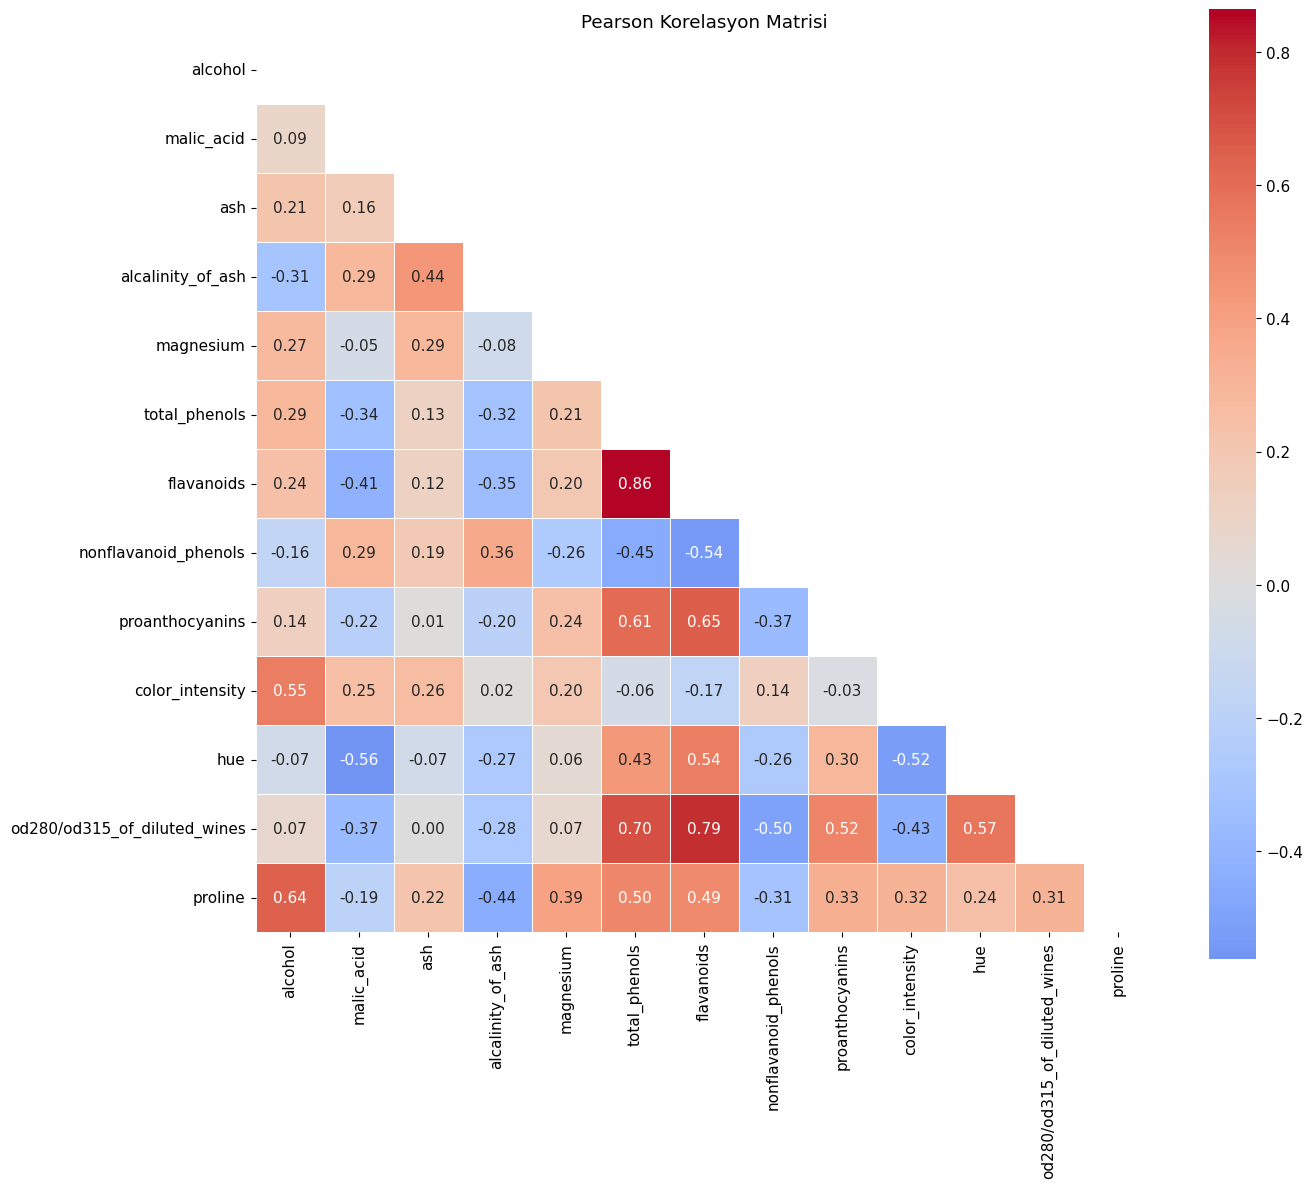

En yuksek korelasyonlu 3 cift:
  flavanoids - total_phenols: 0.8646
  od280/od315_of_diluted_wines - flavanoids: 0.7872
  od280/od315_of_diluted_wines - total_phenols: 0.6999


In [11]:
corr = X.corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Pearson Korelasyon Matrisi')
plt.tight_layout()
plt.show()

# en yuksek 3 korelasyon cifti
corr_upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
top3       = corr_upper.unstack().dropna().abs().sort_values(ascending=False).head(3)

print("En yuksek korelasyonlu 3 cift:")
for idx, val in top3.items():
    r = corr.loc[idx[0], idx[1]]
    print(f"  {idx[0]} - {idx[1]}: {r:.4f}")

# flavanoids ve total_phenols arasinda guclu pozitif korelasyon var (~0.86).
# Bu ozelliklerin benzer bilgi tasidigi soylenir, PCA bu fazlaligi azaltir.

### 3.3 Boxplot Analizi (Sınıflara Göre)

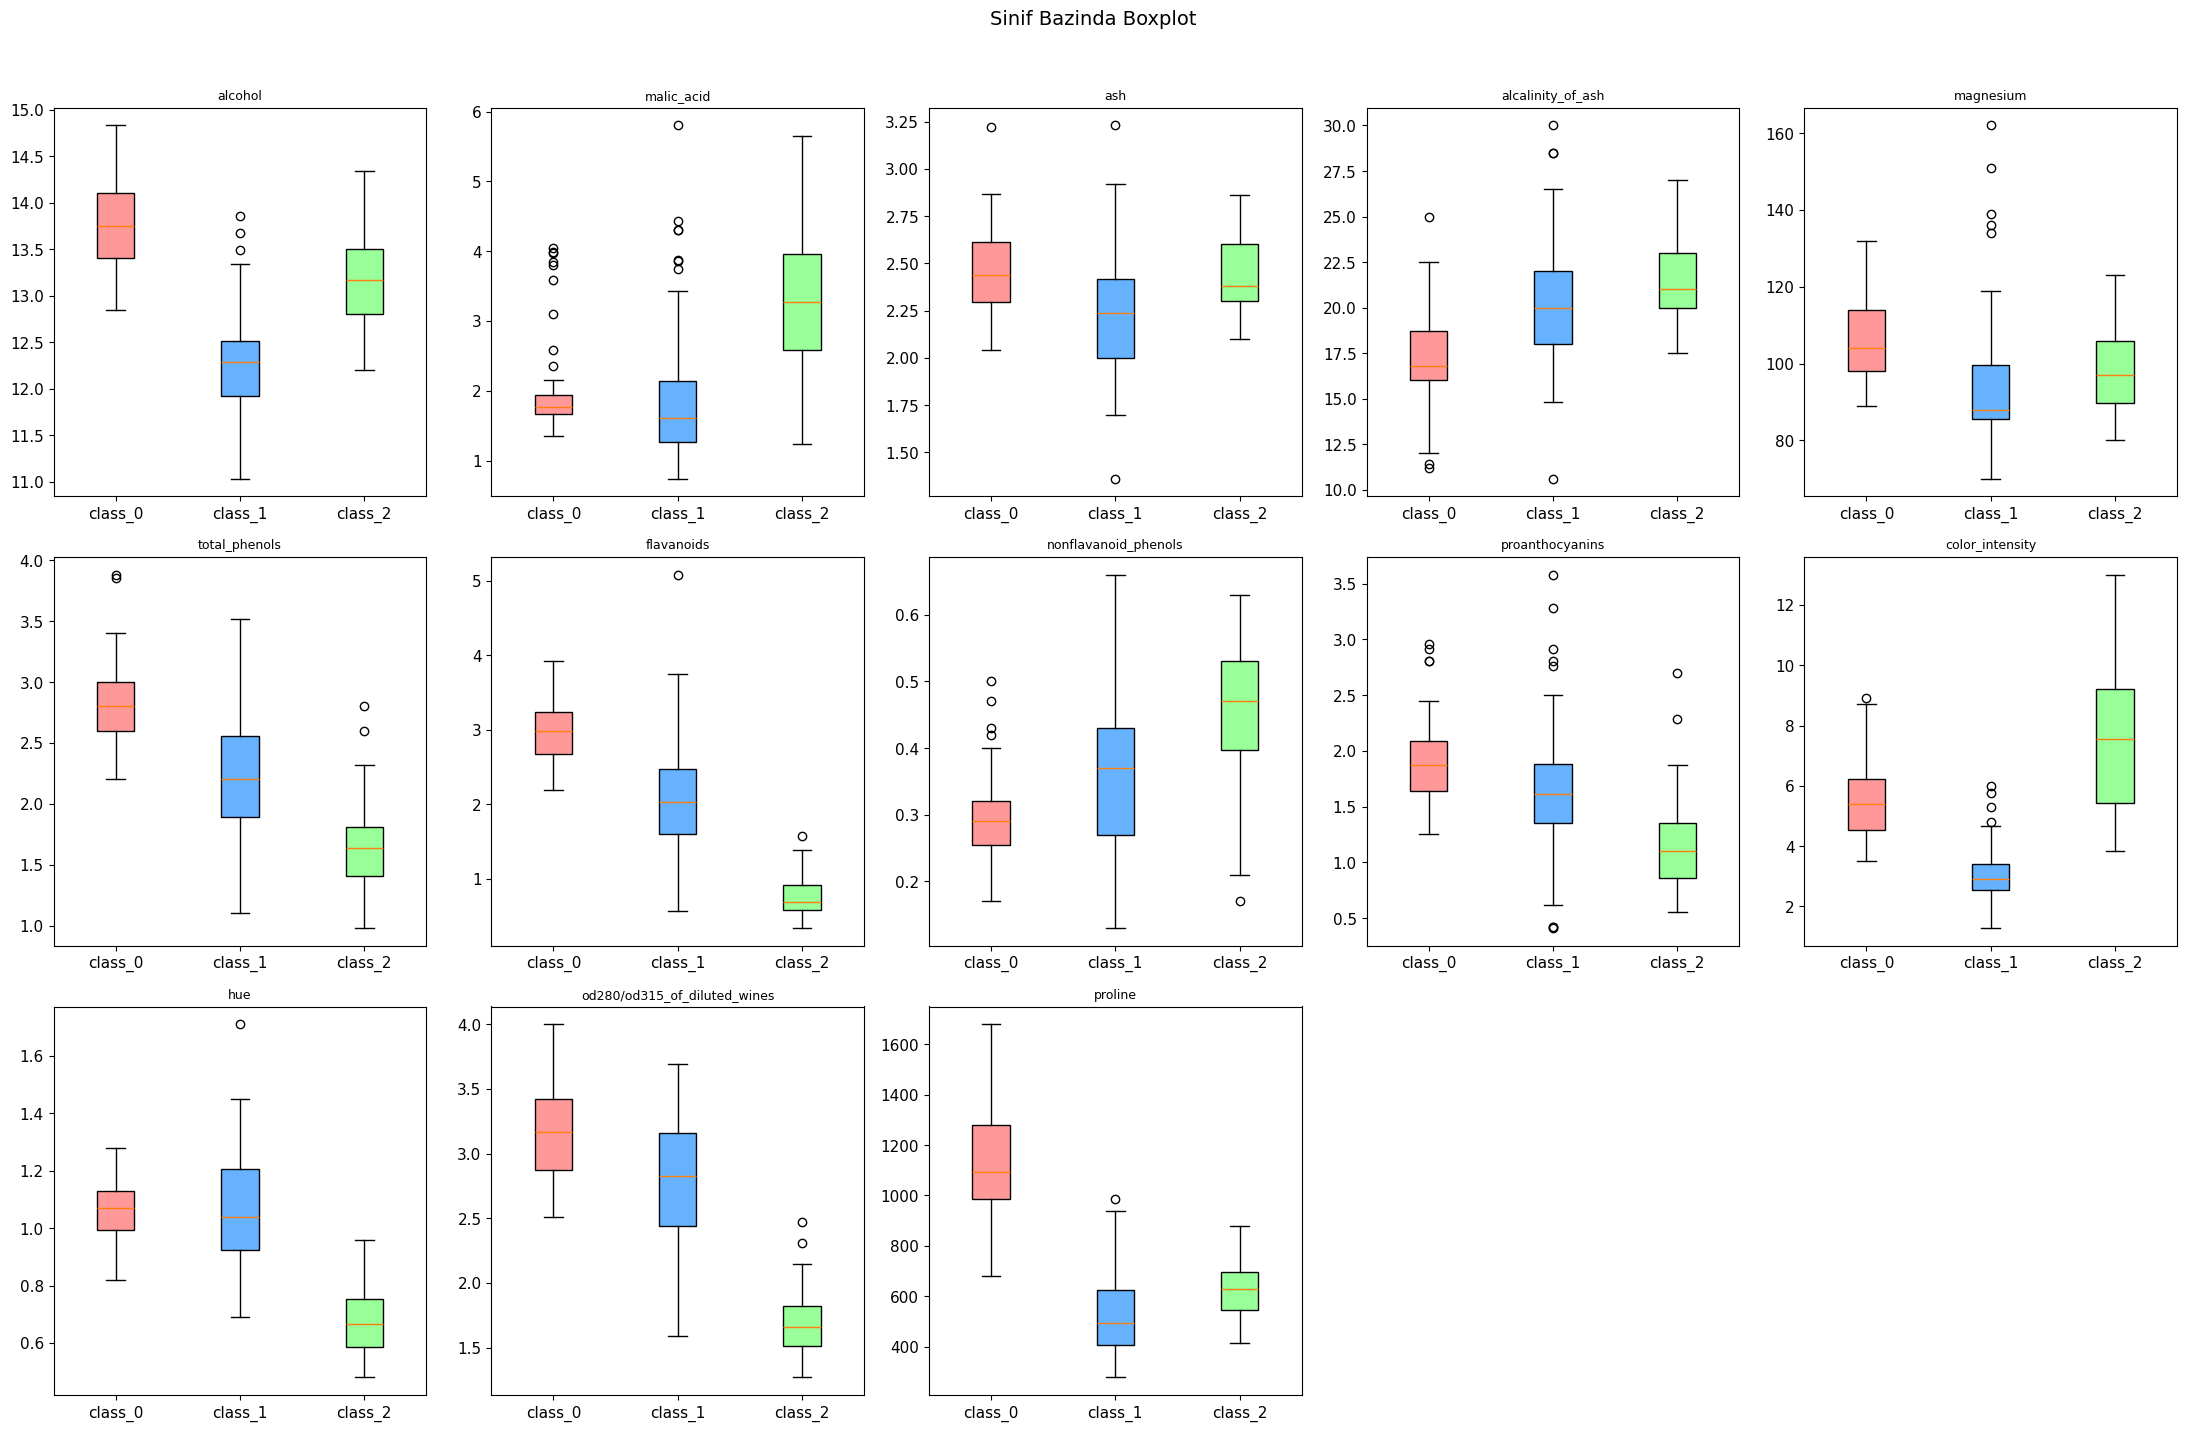

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(22, 14))
axes      = axes.flatten()
renkler   = ['#FF9999', '#66B2FF', '#99FF99']

for i, col in enumerate(X.columns):
    veri = [X[y == c][col].values for c in range(3)]
    bp   = axes[i].boxplot(veri, labels=wine.target_names, patch_artist=True)
    for patch, renk in zip(bp['boxes'], renkler):
        patch.set_facecolor(renk)
    axes[i].set_title(col, fontsize=9)

for i in range(len(X.columns), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Sinif Bazinda Boxplot', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# flavanoids, color_intensity ve proline siniflari net ayiriyor.
# class_0 proline ve flavanoids'te yuksek, class_2 color_intensity'de yuksek.

---
## 4. Veri Setinin Bölünmesi

Veri sızıntısını önlemek için **önce bölme, sonra ölçeklendirme** yapıyoruz.

Oranlar: %70 Train / %10 Validation / %20 Test

In [13]:
# once %80 - %20 ayir, sonra %80'in icinden %70-%10 olustur
X_temp, X_test, y_temp, y_test   = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val   = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

print(f"Train      : {X_train.shape[0]} ornek ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation : {X_val.shape[0]} ornek ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test       : {X_test.shape[0]} ornek ({X_test.shape[0]/len(X)*100:.1f}%)")

Train      : 124 ornek (69.7%)
Validation : 18 ornek (10.1%)
Test       : 36 ornek (20.2%)


---
## 5. Veri Ölçeklendirme

StandardScaler sadece train üzerinde fit ediliyor.

In [14]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X.columns, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)

print("StandardScaler uygulandi (fit: sadece train).")
print(X_train_scaled.describe().loc[['mean','std']].round(4))

StandardScaler uygulandi (fit: sadece train).
      alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
mean  -0.0000      0.0000  0.0000             0.0000    -0.0000   
std    1.0041      1.0041  1.0041             1.0041     1.0041   

      total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
mean         0.0000      0.0000                0.0000          -0.0000   
std          1.0041      1.0041                1.0041           1.0041   

      color_intensity     hue  od280/od315_of_diluted_wines  proline  
mean          -0.0000 -0.0000                        0.0000  -0.0000  
std            1.0041  1.0041                        1.0041   1.0041  


---
## 6. Boyut İndirgeme

Üç veri temsili oluşturuyoruz: **Ham veri**, **PCA**, **LDA**

### 6.1 PCA

Bileşen sayısını explained variance ratio ortalamasından büyük olanları seçerek belirliyoruz.

In [15]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

ev_ratio     = pca_full.explained_variance_ratio_
ev_cumsum    = np.cumsum(ev_ratio)
ev_ortalama  = np.mean(ev_ratio)
n_pca        = int(np.sum(ev_ratio > ev_ortalama))

print(f"Ortalama EV ratio: {ev_ortalama:.4f}")
print(f"Secilen bilesen sayisi: {n_pca}\n")

for i, (ev, cv) in enumerate(zip(ev_ratio, ev_cumsum)):
    isaret = " <--" if ev > ev_ortalama else ""
    print(f"  PC{i+1:2d}: {ev:.4f}  (kumulatif: {cv:.4f}){isaret}")

Ortalama EV ratio: 0.0769
Secilen bilesen sayisi: 3

  PC 1: 0.3648  (kumulatif: 0.3648) <--
  PC 2: 0.1938  (kumulatif: 0.5586) <--
  PC 3: 0.1132  (kumulatif: 0.6718) <--
  PC 4: 0.0727  (kumulatif: 0.7445)
  PC 5: 0.0593  (kumulatif: 0.8038)
  PC 6: 0.0476  (kumulatif: 0.8514)
  PC 7: 0.0450  (kumulatif: 0.8965)
  PC 8: 0.0248  (kumulatif: 0.9213)
  PC 9: 0.0234  (kumulatif: 0.9446)
  PC10: 0.0182  (kumulatif: 0.9628)
  PC11: 0.0175  (kumulatif: 0.9803)
  PC12: 0.0127  (kumulatif: 0.9930)
  PC13: 0.0070  (kumulatif: 1.0000)


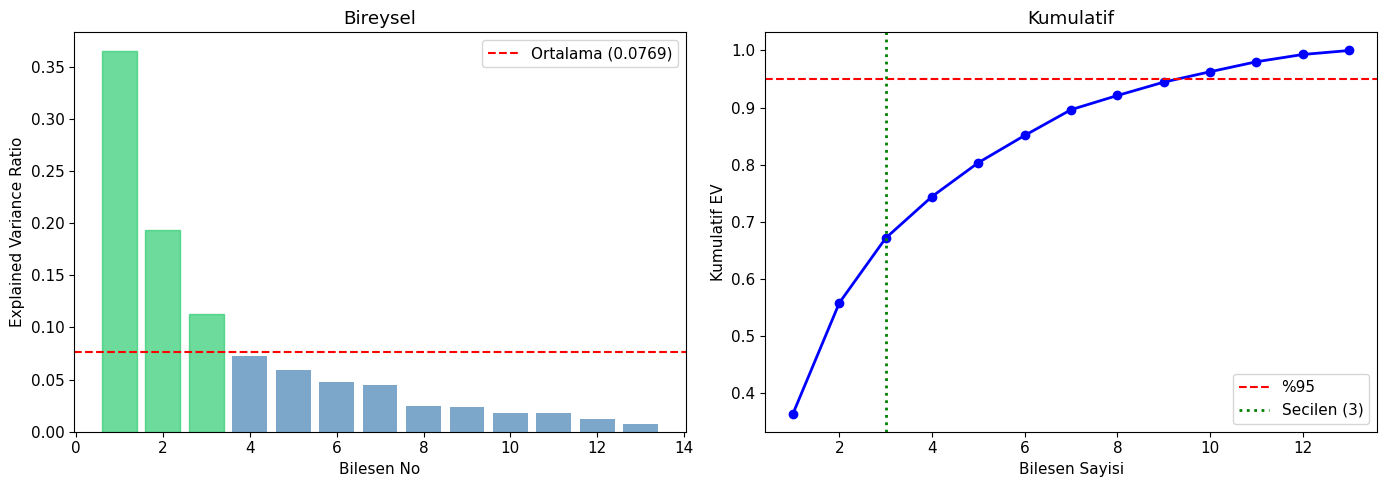

In [16]:
# Explained Variance grafigi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(range(1, len(ev_ratio)+1), ev_ratio, alpha=0.7, color='steelblue')
for i in range(n_pca):
    bars[i].set_color('#2ecc71')
ax1.axhline(y=ev_ortalama, color='red', linestyle='--', label=f'Ortalama ({ev_ortalama:.4f})')
ax1.set_xlabel('Bilesen No')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Bireysel')
ax1.legend()

ax2.plot(range(1, len(ev_ratio)+1), ev_cumsum, 'bo-', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', label='%95')
ax2.axvline(x=n_pca, color='green', linestyle=':', linewidth=2, label=f'Secilen ({n_pca})')
ax2.set_xlabel('Bilesen Sayisi')
ax2.set_ylabel('Kumulatif EV')
ax2.set_title('Kumulatif')
ax2.legend()

plt.tight_layout()
plt.show()

13 ozellik -> 3 bilesen
Toplam aciklanan varyans: 0.6718


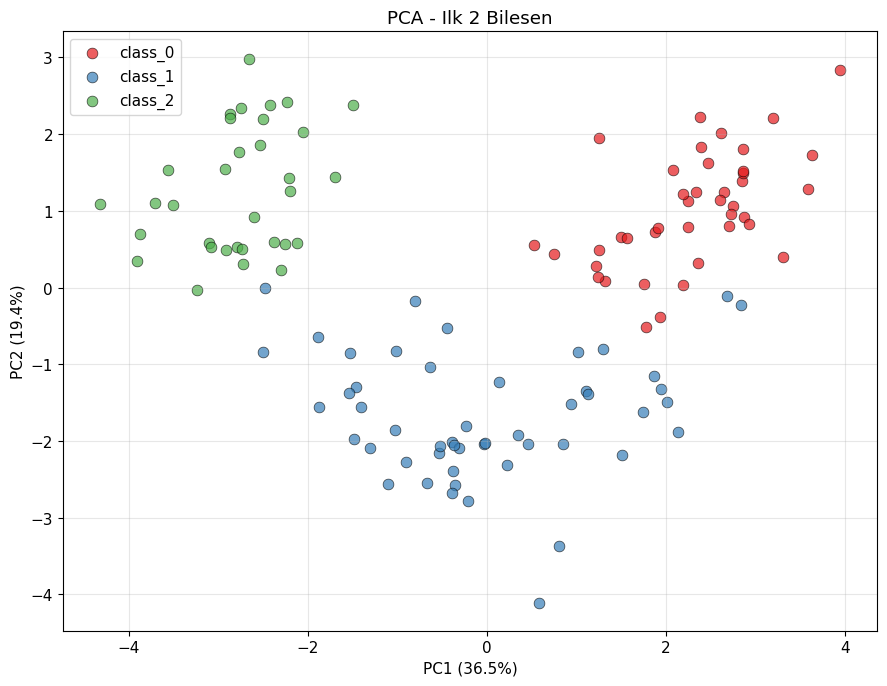

In [17]:
pca = PCA(n_components=n_pca)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"{X_train_scaled.shape[1]} ozellik -> {n_pca} bilesen")
print(f"Toplam aciklanan varyans: {sum(pca.explained_variance_ratio_):.4f}")

# 2D scatter
renk_map = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a'}

plt.figure(figsize=(9, 7))
for c in range(3):
    m = (y_train.values == c)
    plt.scatter(X_train_pca[m, 0], X_train_pca[m, 1],
                c=renk_map[c], label=wine.target_names[c],
                alpha=0.7, edgecolors='k', s=60, linewidths=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA - Ilk 2 Bilesen')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# class_0 diger siniflardan net bir sekilde ayrisiyor.

### 6.2 LDA (Linear Discriminant Analysis)

**Önemli Matematiksel Not:** Ödev şartnamesi `n_components = 3` belirtmiştir; ancak LDA'da maksimum bileşen sayısı **min(n_features, n_classes − 1)** formülüyle hesaplanır.

Wine veri setinde 3 sınıf bulunduğundan: `n_components_max = min(13, 3−1) = 2`

Dolayısıyla `n_components = 3` talep edilse dahi scikit-learn otomatik olarak **2** bileşen üretir. Bu durum aşağıdaki kodda gösterilmiş ve gerekçesi açıklanmıştır.

Sinif sayisi        : 3
Istenen n_components: 3
Matematiksel limit  : min(13, 3-1) = 2
Kullanilan n_lda    : 2  (scikit-learn max degeri otomatik uygular)

LDA: 13 ozellik -> 2 bilesen
Explained variance ratio: [0.6934 0.3066]
LD1 varyans aciklama orani: %69.3
LD2 varyans aciklama orani: %30.7


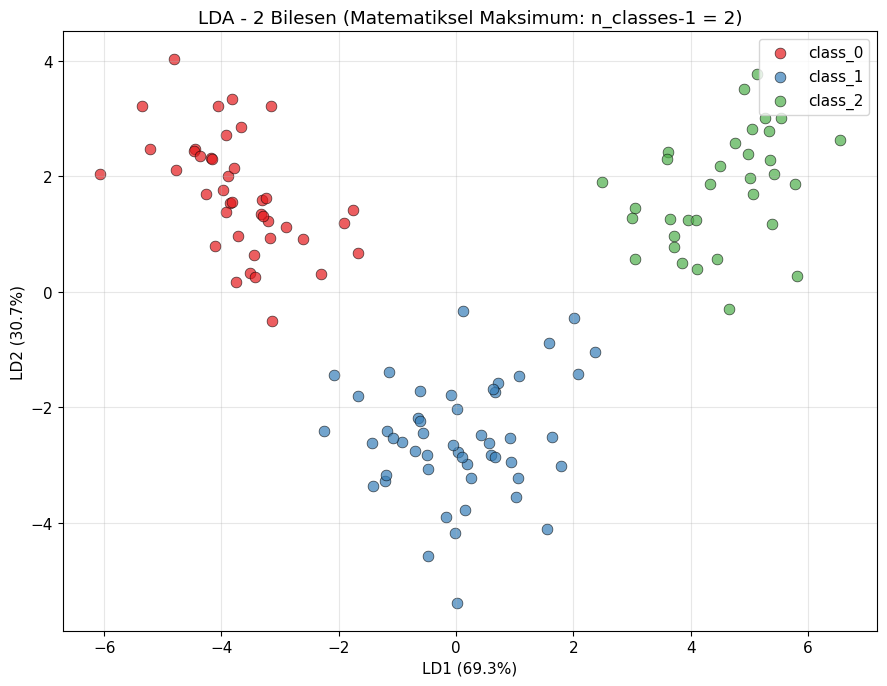

In [18]:
# Matematiksel limit: LDA max bilesen = min(n_features, n_classes - 1)
n_classes      = len(np.unique(y_train))
n_lda_requested = 3   # odevde istenen deger
n_lda_max      = min(X_train_scaled.shape[1], n_classes - 1)   # = 2
n_lda          = min(n_lda_requested, n_lda_max)                # gercekte kullanilan

print(f"Sinif sayisi        : {n_classes}")
print(f"Istenen n_components: {n_lda_requested}")
print(f"Matematiksel limit  : min({X_train_scaled.shape[1]}, {n_classes}-1) = {n_lda_max}")
print(f"Kullanilan n_lda    : {n_lda}  (scikit-learn max degeri otomatik uygular)")
print()

lda = LDA(n_components=n_lda)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda   = lda.transform(X_val_scaled)
X_test_lda  = lda.transform(X_test_scaled)

print(f"LDA: {X_train_scaled.shape[1]} ozellik -> {n_lda} bilesen")
print(f"Explained variance ratio: {lda.explained_variance_ratio_.round(4)}")
print(f"LD1 varyans aciklama orani: %{lda.explained_variance_ratio_[0]*100:.1f}")
print(f"LD2 varyans aciklama orani: %{lda.explained_variance_ratio_[1]*100:.1f}")

renk_map = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a'}

plt.figure(figsize=(9, 7))
for c in range(3):
    m = (y_train.values == c)
    plt.scatter(X_train_lda[m, 0], X_train_lda[m, 1],
                c=renk_map[c], label=wine.target_names[c],
                alpha=0.7, edgecolors='k', s=60, linewidths=0.5)

plt.xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
plt.title('LDA - 2 Bilesen (Matematiksel Maksimum: n_classes-1 = 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# LDA sinif bilgisini kullandigi icin PCA'dan cok daha net ayrim sagliyor.
# Uc sinif tamamen birbirinden ayrisarak hicbir cakisma gozuklemiyor.
# LD1 tek basina varyansın %69.3'unu, LD2 ise %30.7'sini acikliyor.


---
## 7-8. Model Eğitimi & Validation

5 algoritma x 3 veri temsili = **15 model**

In [19]:
modeller = {
    'Logistic Regression' : LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial'),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0),
    'Naive Bayes'         : GaussianNB()
}

pca_cols = [f'PC{i+1}' for i in range(n_pca)]
lda_cols = [f'LD{i+1}' for i in range(n_lda)]

veri_setleri = {
    'Ham Veri' : {'train': X_train_scaled,
                  'val'  : X_val_scaled,
                  'test' : X_test_scaled},
    'PCA'      : {'train': pd.DataFrame(X_train_pca, columns=pca_cols),
                  'val'  : pd.DataFrame(X_val_pca,   columns=pca_cols),
                  'test' : pd.DataFrame(X_test_pca,  columns=pca_cols)},
    'LDA'      : {'train': pd.DataFrame(X_train_lda, columns=lda_cols),
                  'val'  : pd.DataFrame(X_val_lda,   columns=lda_cols),
                  'test' : pd.DataFrame(X_test_lda,  columns=lda_cols)}
}

sonuclar       = []
egitilen_model = {}
y_val_bin      = label_binarize(y_val, classes=[0, 1, 2])

for veri_adi, veri in veri_setleri.items():
    for model_adi, sablon in modeller.items():
        mdl = clone(sablon)
        mdl.fit(veri['train'], y_train)

        tahmin = mdl.predict(veri['val'])
        proba  = mdl.predict_proba(veri['val'])

        acc  = accuracy_score(y_val, tahmin)
        prec = precision_score(y_val, tahmin, average='weighted', zero_division=0)
        rec  = recall_score(y_val, tahmin, average='weighted', zero_division=0)
        f1   = f1_score(y_val, tahmin, average='weighted', zero_division=0)
        rocv = roc_auc_score(y_val_bin, proba, multi_class='ovr', average='weighted')

        sonuclar.append({
            'Veri'      : veri_adi,
            'Model'     : model_adi,
            'Accuracy'  : round(acc, 4),
            'Precision' : round(prec, 4),
            'Recall'    : round(rec, 4),
            'F1-Score'  : round(f1, 4),
            'ROC-AUC'   : round(rocv, 4)
        })
        egitilen_model[(veri_adi, model_adi)] = mdl

print(f"{len(sonuclar)} model egitildi.")

15 model egitildi.


### Validation Karşılaştırma Tablosu

In [20]:
sonuc_df = pd.DataFrame(sonuclar)

styled = sonuc_df.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
    color='lightgreen'
).format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']})
display(styled)

print("\nVeri temsiline gore ortalama:")
print(sonuc_df.groupby('Veri')[['Accuracy','F1-Score','ROC-AUC']].mean().round(4))

,Veri,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Ham Veri,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Ham Veri,Decision Tree,0.9444,0.9514,0.9444,0.9438,0.9545
2,Ham Veri,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,Ham Veri,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
4,Ham Veri,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000
5,PCA,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
6,PCA,Decision Tree,0.8889,0.8889,0.8889,0.8889,0.9129
7,PCA,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
8,PCA,XGBoost,0.9444,0.9514,0.9444,0.9432,1.0000
9,PCA,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000



Veri temsiline gore ortalama:
          Accuracy  F1-Score  ROC-AUC
Veri                                 
Ham Veri    0.9889    0.9888   0.9909
LDA         1.0000    1.0000   1.0000
PCA         0.9667    0.9664   0.9826


### Validation Sonuçlarının Görsel Karşılaştırması

Tabloyu destekleyen görsel: 15 modelin F1-Score'unu grup bazında karşılaştıran grouped bar chart.

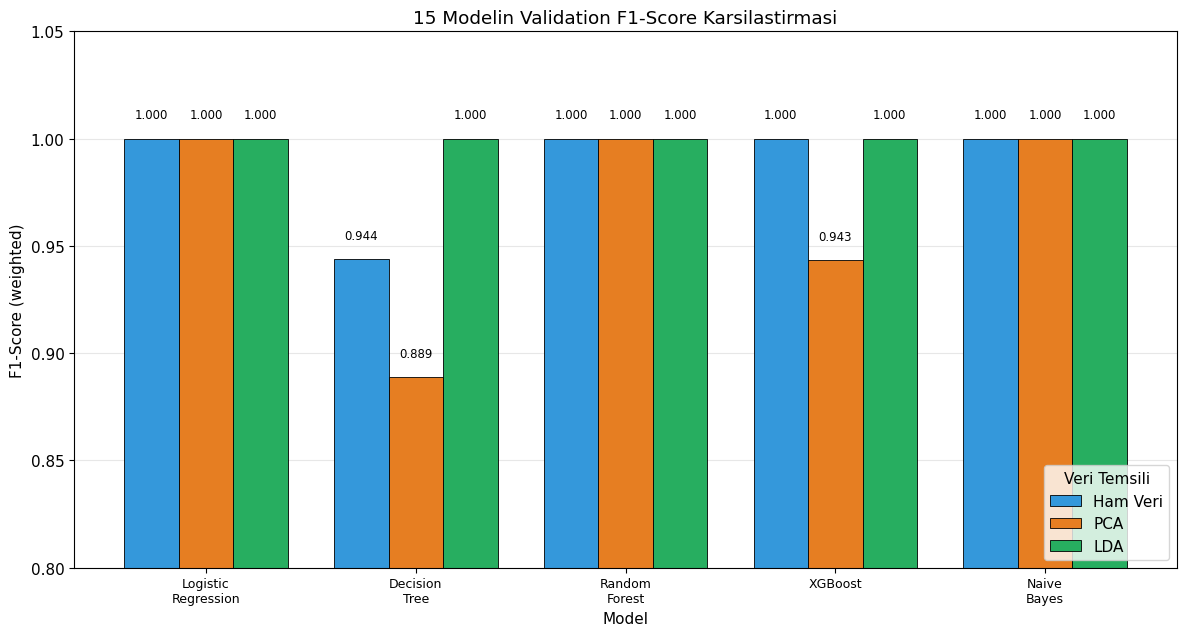

In [21]:
# 15 model validation F1-Score karsilastirma grafigi
model_adlari = list(modeller.keys())
x            = np.arange(len(model_adlari))
genislik     = 0.26

f1_ham = sonuc_df[sonuc_df['Veri']=='Ham Veri']['F1-Score'].values
f1_pca = sonuc_df[sonuc_df['Veri']=='PCA']['F1-Score'].values
f1_lda = sonuc_df[sonuc_df['Veri']=='LDA']['F1-Score'].values

fig, ax = plt.subplots(figsize=(12, 6.5))
b1 = ax.bar(x - genislik, f1_ham, genislik, label='Ham Veri', color='#3498db', edgecolor='black', linewidth=0.6)
b2 = ax.bar(x,            f1_pca, genislik, label='PCA',      color='#e67e22', edgecolor='black', linewidth=0.6)
b3 = ax.bar(x + genislik, f1_lda, genislik, label='LDA',      color='#27ae60', edgecolor='black', linewidth=0.6)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('F1-Score (weighted)')
ax.set_xlabel('Model')
ax.set_title('15 Modelin Validation F1-Score Karsilastirmasi')
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', chr(10)) for m in model_adlari], fontsize=9)
ax.set_ylim([0.80, 1.05])
ax.legend(title='Veri Temsili', loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Gozlemler:
# - LDA tum algoritmalarda 1.000 F1-Score vermis
# - Ham veride Decision Tree 0.944 ile digerlerinden dusuk
# - PCA'da Decision Tree ve XGBoost hafif dusus yasiyor
# - Birden fazla model 1.000 oldugu icin test performansi secimde belirleyici

---
## 9. En İyi Modelin Test Değerlendirmesi

In [22]:
best_idx  = sonuc_df['F1-Score'].idxmax()
best_row  = sonuc_df.loc[best_idx]
best_veri = best_row['Veri']
best_mdl  = best_row['Model']

print(f"En iyi model: {best_mdl} ({best_veri})")
print(f"Val F1: {best_row['F1-Score']}  |  Val AUC: {best_row['ROC-AUC']}")

model      = egitilen_model[(best_veri, best_mdl)]
X_test_en  = veri_setleri[best_veri]['test']
y_pred     = model.predict(X_test_en)
y_proba    = model.predict_proba(X_test_en)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

En iyi model: Logistic Regression (Ham Veri)
Val F1: 1.0  |  Val AUC: 1.0


### 9.1 Test Metrikleri

In [23]:
t_acc  = accuracy_score(y_test, y_pred)
t_prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
t_rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
t_f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
t_roc  = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')

print(f"Accuracy  : {t_acc:.4f}")
print(f"Precision : {t_prec:.4f}")
print(f"Recall    : {t_rec:.4f}")
print(f"F1-Score  : {t_f1:.4f}")
print(f"ROC-AUC   : {t_roc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Accuracy  : 0.9722
Precision : 0.9741
Recall    : 0.9722
F1-Score  : 0.9720
ROC-AUC   : 1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



### 9.2 Confusion Matrix

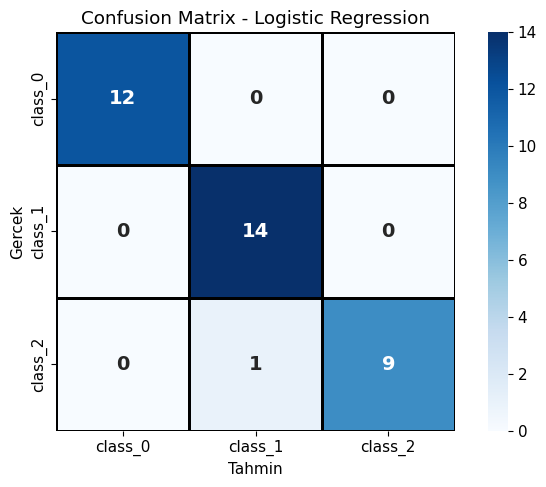

Dogru tahmin: 35/36 (97.2%)


In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names,
            linewidths=1, linecolor='black', square=True,
            annot_kws={"size": 14, "fontweight": "bold"})
plt.title(f'Confusion Matrix - {best_mdl}')
plt.ylabel('Gercek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

dogru = np.trace(cm)
print(f"Dogru tahmin: {dogru}/{cm.sum()} ({dogru/cm.sum()*100:.1f}%)")

### 9.3 ROC Eğrisi

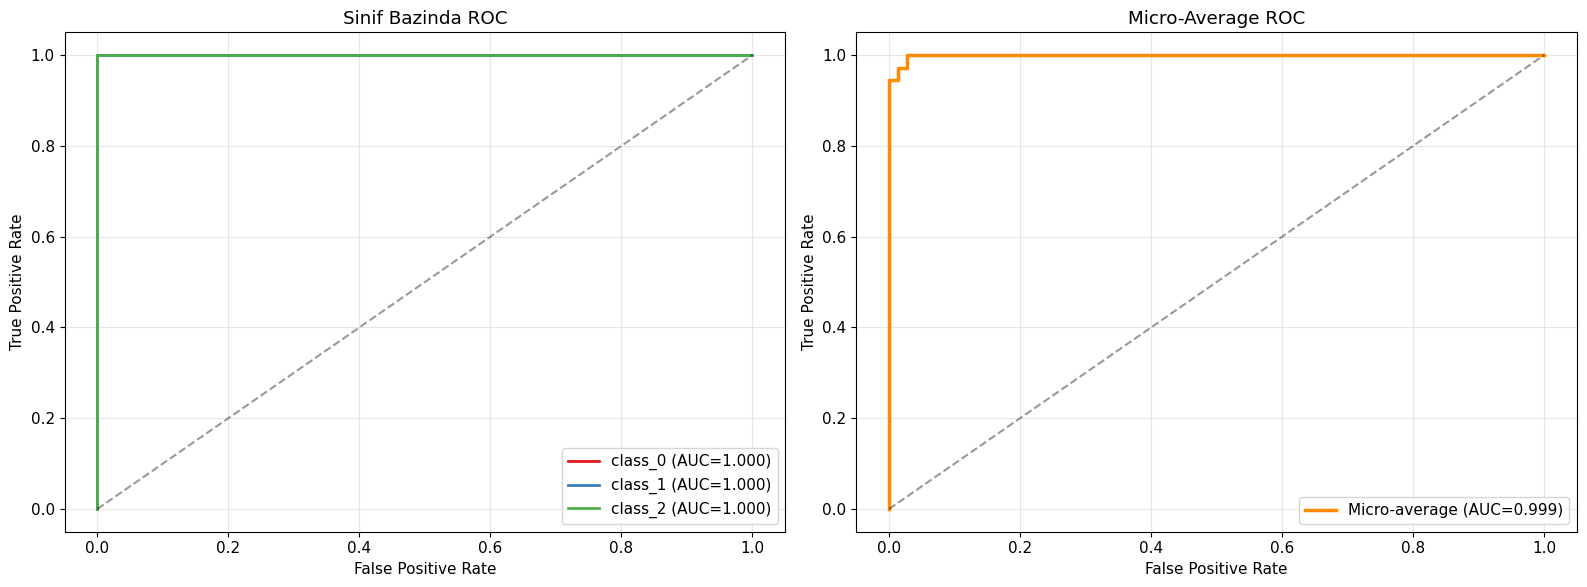

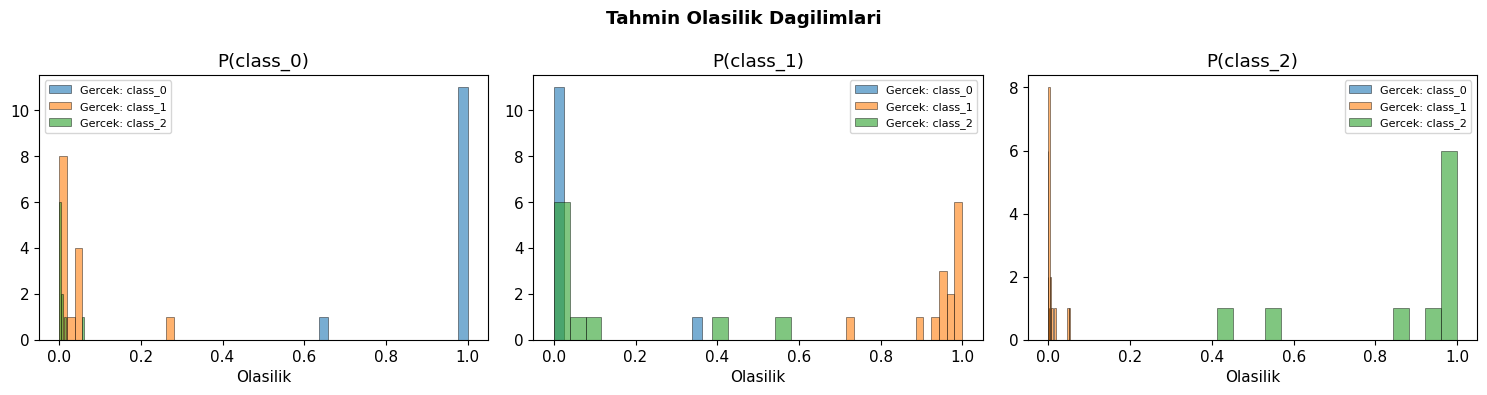

In [25]:
fpr, tpr, roc_val = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_val[i]        = auc(fpr[i], tpr[i])

# micro-average ROC (tum siniflari birlestir)
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_micro               = auc(fpr_micro, tpr_micro)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# sol: sinif bazinda
renkler_roc = ['#e41a1c', '#377eb8', '#4daf4a']
for i, r in enumerate(renkler_roc):
    ax1.step(fpr[i], tpr[i], color=r, linewidth=2, where='post',
             label=f'{wine.target_names[i]} (AUC={roc_val[i]:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Sinif Bazinda ROC')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# sag: micro-average + olasilik dagilimi
ax2.step(fpr_micro, tpr_micro, color='darkorange', linewidth=2.5, where='post',
         label=f'Micro-average (AUC={auc_micro:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Micro-Average ROC')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# AUC=1.0 siniflarda olasilik tahminleri tum ornekleri dogru siralamis demek.
# 1 yanlis tahmin olmasina ragmen, o ornegin olasilik skoru diger siniftan
# hala dusuk oldugu icin AUC etkilenmiyor (AUC ranking bazli bir metriktir).

# Olasilik dagilimlarini da gosterelim
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    for c in range(3):
        mask = (y_test.values == c)
        axes[i].hist(y_proba[mask, i], bins=15, alpha=0.6,
                     label=f'Gercek: {wine.target_names[c]}', edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'P({wine.target_names[i]})')
    axes[i].set_xlabel('Olasilik')
    axes[i].legend(fontsize=8)
plt.suptitle('Tahmin Olasilik Dagilimlari', fontweight='bold')
plt.tight_layout()
plt.show()

# Olasilik dagilimlari gosteriyor ki siniflar birbirinden net ayrisiyor,
# bu da yuksek AUC degerlerini acikliyor.

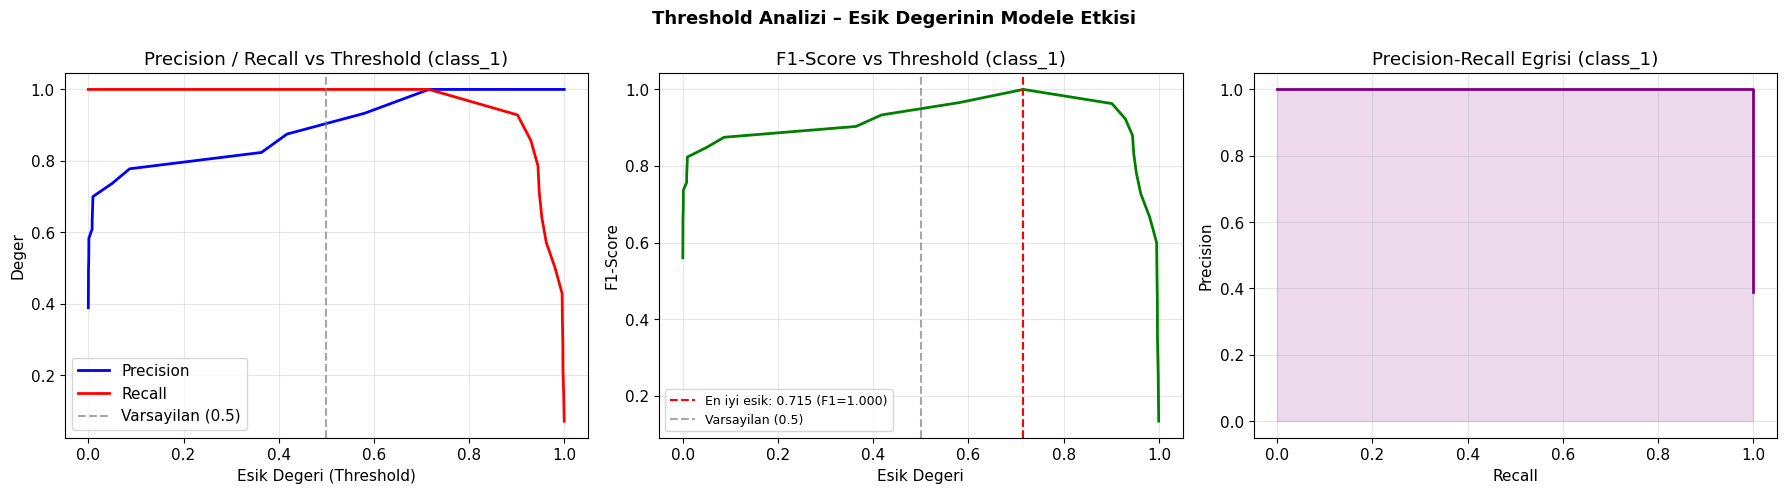

Varsayilan esik (0.5) ile class_1 sonuclari:
  Precision=0.9333  Recall=1.0000  F1=0.9655

En iyi esik (0.715) ile class_1 sonuclari:
  Precision=1.0000  Recall=1.0000  F1=1.0000

Threshold Yorumu:
  - Esik degerini ARTIRMAK: Precision artar, Recall duser.
    (Daha az ama daha guvenilir pozitif tahmin)
  - Esik degerini AZALTMAK: Recall artar, Precision duser.
    (Daha fazla pozitif tahmin ama yanlis alarm riski artar)
  - Wine siniflandirmasinda dengeli F1 icin 0.5 zaten iyi bir baslangic noktasidir.
  - Medikal veya guvenllik uygulamalarinda Recall oncelikli olacagindan
    esik 0.3-0.4'e indirilmesi tercih edilir.


In [26]:
# ---- 9.3 Ek: Threshold (Esik Degeri) Analizi ----
from sklearn.metrics import precision_recall_curve

# Ikili (binary) karsilastirma icin class_1 (en zor sinif) kullaniliyor
y_test_bin_1 = y_test_bin[:, 1]  # class_1 gercek etiketleri
y_proba_1    = y_proba[:, 1]      # class_1 tahmin olasiliklarci

prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test_bin_1, y_proba_1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Sol: Precision - Recall vs Threshold ---
axes[0].plot(thr_arr, prec_arr[:-1], 'b-', linewidth=2, label='Precision')
axes[0].plot(thr_arr, rec_arr[:-1],  'r-', linewidth=2, label='Recall')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Varsayilan (0.5)')
axes[0].set_xlabel('Esik Degeri (Threshold)')
axes[0].set_ylabel('Deger')
axes[0].set_title('Precision / Recall vs Threshold (class_1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Orta: F1 vs Threshold ---
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
best_t_idx = np.argmax(f1_arr)
best_t     = thr_arr[best_t_idx]
axes[1].plot(thr_arr, f1_arr, 'g-', linewidth=2)
axes[1].axvline(x=best_t, color='red', linestyle='--',
                label=f'En iyi esik: {best_t:.3f} (F1={f1_arr[best_t_idx]:.3f})')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Varsayilan (0.5)')
axes[1].set_xlabel('Esik Degeri')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score vs Threshold (class_1)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Sag: Precision-Recall Egrisi ---
axes[2].step(rec_arr, prec_arr, where='post', color='purple', linewidth=2)
axes[2].fill_between(rec_arr, prec_arr, alpha=0.15, color='purple', step='post')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Egrisi (class_1)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Threshold Analizi – Esik Degerinin Modele Etkisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Varsayilan esik (0.5) ile class_1 sonuclari:")
y_pred_default = (y_proba_1 >= 0.5).astype(int)
p_def = precision_score(y_test_bin_1, y_pred_default, zero_division=0)
r_def = recall_score(y_test_bin_1, y_pred_default, zero_division=0)
f_def = f1_score(y_test_bin_1, y_pred_default, zero_division=0)
print(f"  Precision={p_def:.4f}  Recall={r_def:.4f}  F1={f_def:.4f}")

print(f"\nEn iyi esik ({best_t:.3f}) ile class_1 sonuclari:")
y_pred_best = (y_proba_1 >= best_t).astype(int)
p_best = precision_score(y_test_bin_1, y_pred_best, zero_division=0)
r_best = recall_score(y_test_bin_1, y_pred_best, zero_division=0)
f_best = f1_score(y_test_bin_1, y_pred_best, zero_division=0)
print(f"  Precision={p_best:.4f}  Recall={r_best:.4f}  F1={f_best:.4f}")

print()
print("Threshold Yorumu:")
print("  - Esik degerini ARTIRMAK: Precision artar, Recall duser.")
print("    (Daha az ama daha guvenilir pozitif tahmin)")
print("  - Esik degerini AZALTMAK: Recall artar, Precision duser.")
print("    (Daha fazla pozitif tahmin ama yanlis alarm riski artar)")
print("  - Wine siniflandirmasinda dengeli F1 icin 0.5 zaten iyi bir baslangic noktasidir.")
print("  - Medikal veya guvenllik uygulamalarinda Recall oncelikli olacagindan")
print("    esik 0.3-0.4'e indirilmesi tercih edilir.")


---
## 10. SHAP Açıklanabilirlik Analizi

### 10.1 En İyi Model

In [27]:
X_train_en = veri_setleri[best_veri]['train']
X_test_df  = veri_setleri[best_veri]['test']

def shap_hesapla(mdl, X_tr, X_te):
    if isinstance(mdl, (DecisionTreeClassifier, RandomForestClassifier, XGBClassifier)):
        exp = shap.TreeExplainer(mdl)
    elif isinstance(mdl, LogisticRegression):
        exp = shap.LinearExplainer(mdl, X_tr)
    else:
        exp = shap.KernelExplainer(mdl.predict_proba, shap.sample(X_tr, min(50, len(X_tr))))
    return exp.shap_values(X_te)

print(f"Model: {best_mdl} ({best_veri})")
shap_val = shap_hesapla(model, X_train_en, X_test_df)
print("SHAP degerleri hesaplandi.")

Model: Logistic Regression (Ham Veri)
SHAP degerleri hesaplandi.


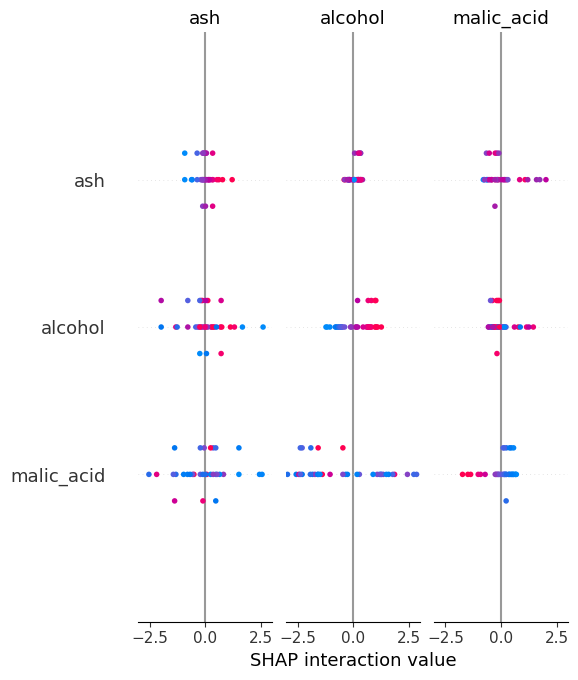

In [28]:
# Summary plot
shap.summary_plot(shap_val, X_test_df, class_names=list(wine.target_names))

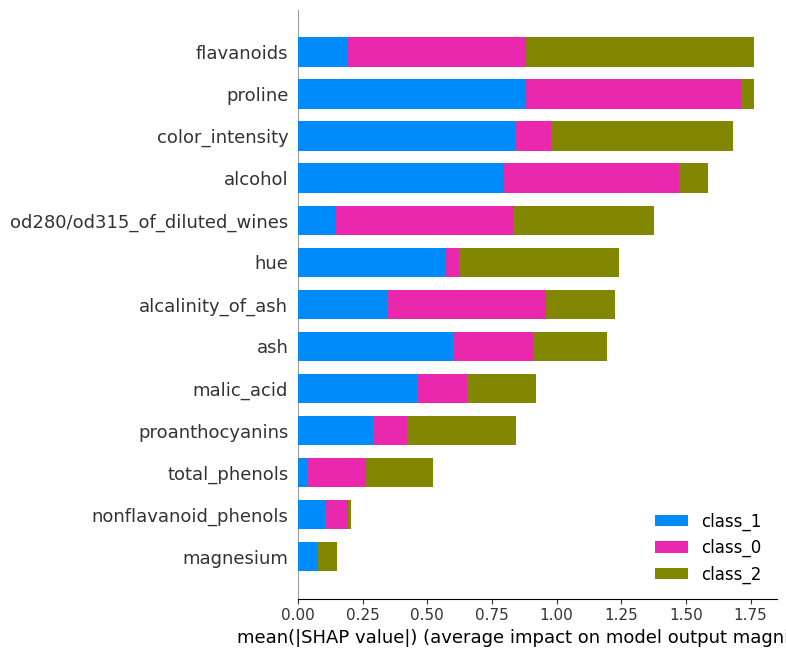

In [29]:
# Bar plot - ortalama etki
shap.summary_plot(shap_val, X_test_df, plot_type="bar",
                  class_names=list(wine.target_names))

In [30]:
# en onemli 5 ozellik
if isinstance(shap_val, list):
    ort_shap = np.mean([np.abs(s).mean(axis=0) for s in shap_val], axis=0)
else:
    arr = np.array(shap_val)
    if arr.ndim == 3:
        ort_shap = np.mean([np.abs(arr[:,:,c]).mean(axis=0) for c in range(arr.shape[2])], axis=0)
    else:
        ort_shap = np.abs(arr).mean(axis=0)

ort_shap = np.asarray(ort_shap).flatten()
cols     = list(X_test_df.columns) if hasattr(X_test_df, 'columns') else [f'F{i}' for i in range(len(ort_shap))]
onem_df  = pd.DataFrame({'Ozellik': cols, 'SHAP': ort_shap}).sort_values('SHAP', ascending=False)

print("Ozellik onem siralamasi:")
for i, (_, r) in enumerate(onem_df.head(5).iterrows()):
    print(f"  {i+1}. {r['Ozellik']:25s}  {r['SHAP']:.4f}")

# SHAP degerleri modelin hangi ozelliklere dayanarak karar verdigini gosteriyor.
# flavanoids ve proline en etkili ozellikler - EDA'daki gozlemlerle tutarli.

Ozellik onem siralamasi:
  1. flavanoids                 0.5879
  2. proline                    0.5878
  3. color_intensity            0.5601
  4. alcohol                    0.5283
  5. od280/od315_of_diluted_wines  0.4593


### 10.2 PCA ve LDA için SHAP Karşılaştırması

PCA en iyi model: Logistic Regression


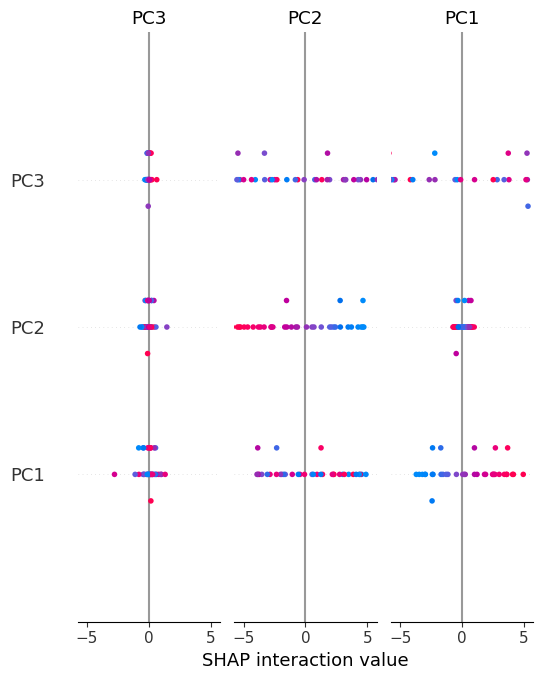

In [31]:
# PCA icin SHAP
pca_sonuc   = sonuc_df[sonuc_df['Veri'] == 'PCA']
pca_en_iyi  = pca_sonuc.loc[pca_sonuc['F1-Score'].idxmax(), 'Model']
pca_mdl     = egitilen_model[('PCA', pca_en_iyi)]

X_tr_pca_df = veri_setleri['PCA']['train']
X_te_pca_df = veri_setleri['PCA']['test']

print(f"PCA en iyi model: {pca_en_iyi}")
shap_pca = shap_hesapla(pca_mdl, X_tr_pca_df, X_te_pca_df)

shap.summary_plot(shap_pca, X_te_pca_df, class_names=list(wine.target_names))

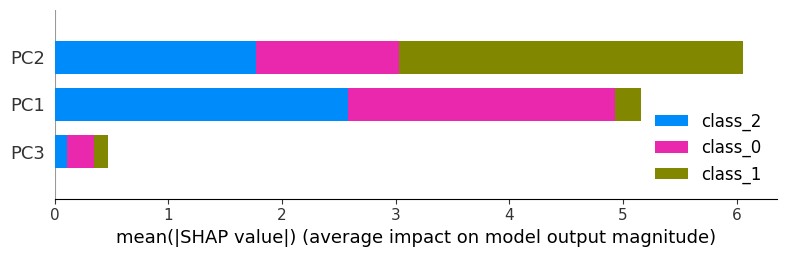

In [32]:
shap.summary_plot(shap_pca, X_te_pca_df, plot_type="bar",
                  class_names=list(wine.target_names))

LDA en iyi model: Logistic Regression


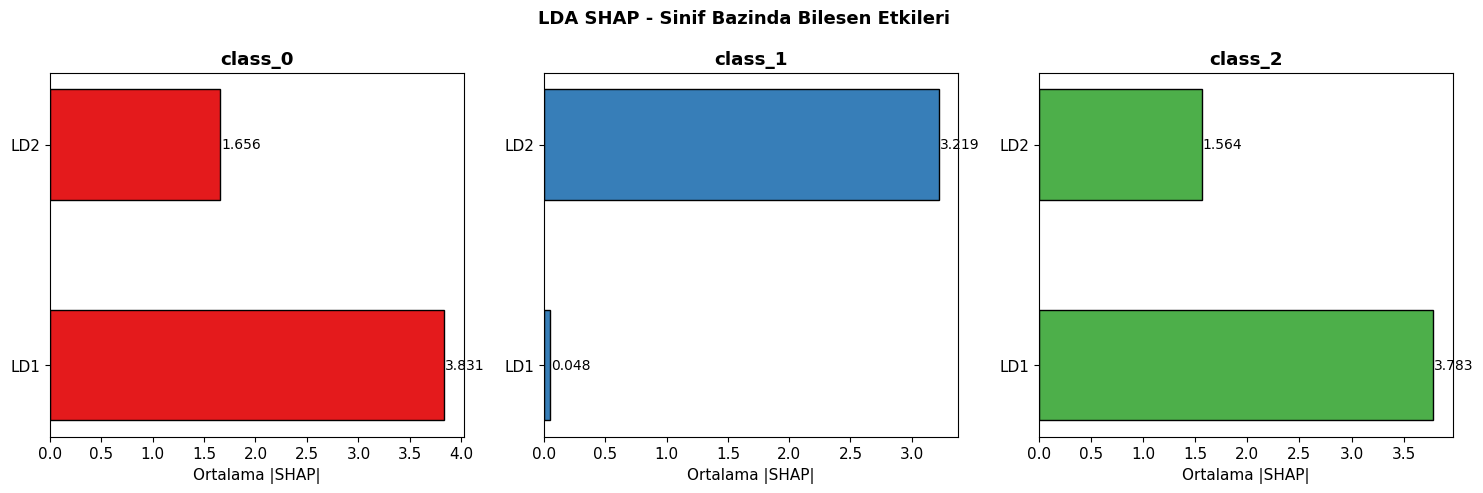

In [33]:
# LDA icin SHAP
lda_sonuc   = sonuc_df[sonuc_df['Veri'] == 'LDA']
lda_en_iyi  = lda_sonuc.loc[lda_sonuc['F1-Score'].idxmax(), 'Model']
lda_mdl     = egitilen_model[('LDA', lda_en_iyi)]

X_tr_lda_df = veri_setleri['LDA']['train']
X_te_lda_df = veri_setleri['LDA']['test']

print(f"LDA en iyi model: {lda_en_iyi}")
shap_lda = shap_hesapla(lda_mdl, X_tr_lda_df, X_te_lda_df)

# LDA'da 2 bilesen < 3 sinif oldugundan summary_plot hata verebilir
# Her durumda calisan bir gorsellestirme yapalim

# shap_lda list veya array olabilir, normalize et
if isinstance(shap_lda, list):
    shap_siniflar = shap_lda
elif isinstance(shap_lda, np.ndarray) and shap_lda.ndim == 3:
    shap_siniflar = [shap_lda[:, :, c] for c in range(shap_lda.shape[2])]
else:
    shap_siniflar = [shap_lda]

bilesen_adlari = list(X_te_lda_df.columns)  # ['LD1', 'LD2']

fig, axes = plt.subplots(1, len(shap_siniflar), figsize=(5*len(shap_siniflar), 5))
if len(shap_siniflar) == 1:
    axes = [axes]

for c, (ax, sv) in enumerate(zip(axes, shap_siniflar)):
    ort = np.abs(sv).mean(axis=0)
    renk = ['#e41a1c', '#377eb8', '#4daf4a']
    ax.barh(bilesen_adlari, ort, color=renk[c % len(renk)], edgecolor='black', height=0.5)
    ax.set_xlabel('Ortalama |SHAP|')
    ax.set_title(f'{wine.target_names[c]}', fontweight='bold')
    for j, v in enumerate(ort):
        ax.text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('LDA SHAP - Sinif Bazinda Bilesen Etkileri', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# LD1 en buyuk etkiye sahip cunku LDA sinif ayrimini maximize eden ilk ekseni LD1 olarak secer.
# LD2 daha az varyans acikliyor dolayisiyla SHAP etkisi de dusuk.

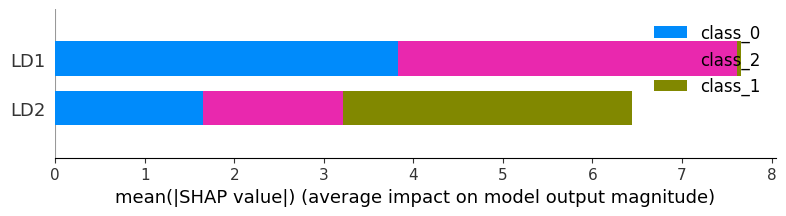

In [34]:
shap.summary_plot(shap_lda, X_te_lda_df, plot_type="bar",
                  class_names=list(wine.target_names))

In [35]:
# Karsilastirma:
# Ham veri SHAP -> orijinal ozelliklerin etkisini dogrudan gosteriyor (en yorumlanabilir)
# PCA SHAP -> PC1 en fazla varyans acikladi, en yuksek etkiye sahip
# LDA SHAP -> LD1 sinif ayrimini maximize ettigi icin en buyuk etkiyi tasiyor
# PCA/LDA bilesenleri orijinal ozelliklerin dogrusal kombinasyonlari, dolayli yorumlanir.
# Boyut indirgemede az bilesen buyuk etki gosterirken, ham veride etki daha dagilmis.

### 10.3 Ek SHAP Görselleri

Notebook çıktılarına ek olarak 4 farklı SHAP görseli:
- **10.3.1** Tekli tahmin açıklaması (waterfall)
- **10.3.2** Özellik bağımlılık grafikleri (dependence plot)
- **10.3.3** Ham/PCA/LDA özellik önem karşılaştırması
- **10.3.4** SHAP ısı haritası

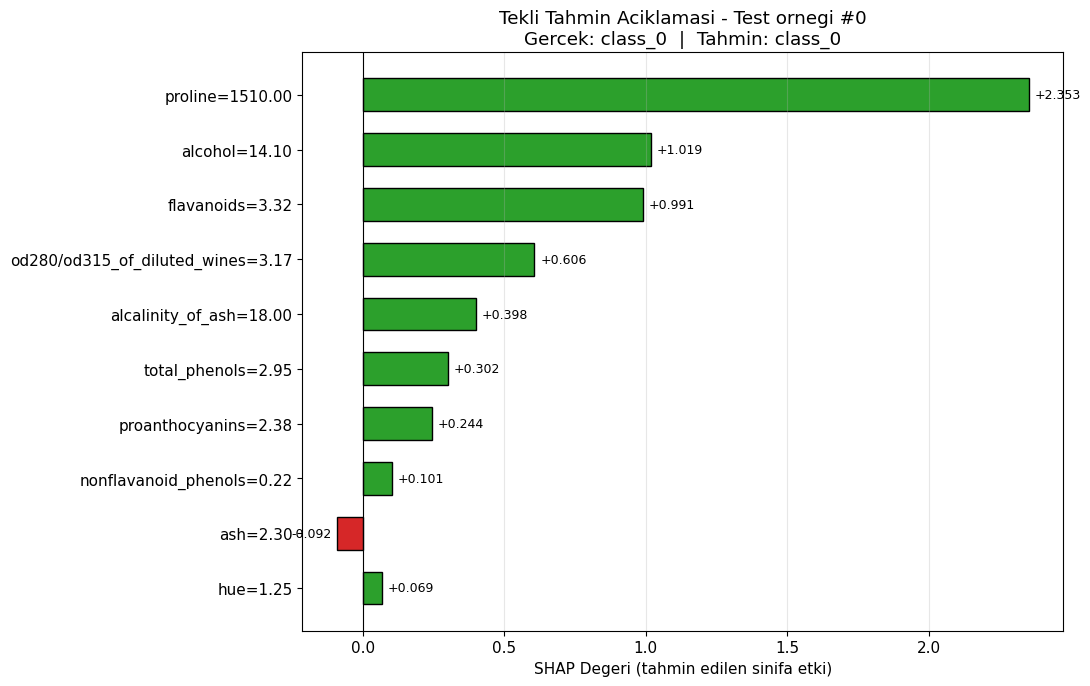

In [36]:
# 10.3.1 Tekli tahmin aciklamasi (waterfall)
# Test setindeki 0 numarali ornek icin
sv_list = shap_val if isinstance(shap_val, list) else [shap_val[:,:,c] for c in range(shap_val.shape[2])]

ornek_idx    = 0
ornek_tahmin = model.predict(X_test_scaled.iloc[[ornek_idx]])[0]
ornek_gercek = y_test.iloc[ornek_idx]

sv_ornek = sv_list[ornek_tahmin][ornek_idx]
sirali   = np.argsort(np.abs(sv_ornek))[::-1][:10]
values   = sv_ornek[sirali]
labels   = [X.columns[i] for i in sirali]
ham      = X_test.iloc[ornek_idx, sirali].values

fig, ax = plt.subplots(figsize=(11, 7))
renkler = ['#d62728' if v < 0 else '#2ca02c' for v in values]
ax.barh(np.arange(len(labels)), values, color=renkler, edgecolor='black', height=0.6)
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels([f'{l}={v:.2f}' for l, v in zip(labels, ham)])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Degeri (tahmin edilen sinifa etki)')
ax.set_title(f'Tekli Tahmin Aciklamasi - Test ornegi #{ornek_idx}\n'
             f'Gercek: {wine.target_names[ornek_gercek]}  |  Tahmin: {wine.target_names[ornek_tahmin]}')
for i, v in enumerate(values):
    ax.text(v + (0.02 if v > 0 else -0.02), i, f'{v:+.3f}',
            va='center', ha='left' if v > 0 else 'right', fontsize=9)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# proline ve alcohol ornegin class_0 siniflandirilmasinda en buyuk pozitif katki

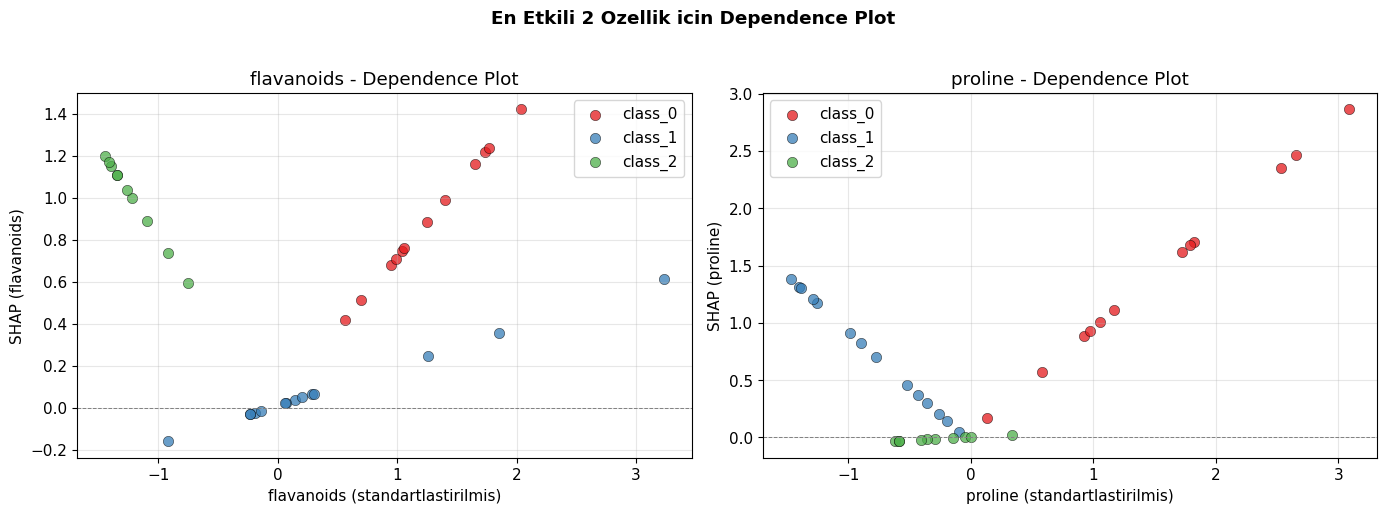

In [37]:
# 10.3.2 Dependence plot - en etkili 2 ozellik
ort_mutlak = np.mean([np.abs(sv).mean(axis=0) for sv in sv_list], axis=0)
top2_idx   = np.argsort(ort_mutlak)[::-1][:2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fi in zip(axes, top2_idx):
    feat_name = X.columns[fi]
    x_vals    = X_test_scaled.iloc[:, fi].values
    for c, rk in enumerate(['#e41a1c', '#377eb8', '#4daf4a']):
        m = (y_test.values == c)
        ax.scatter(x_vals[m], sv_list[c][m, fi], c=rk, label=wine.target_names[c],
                   alpha=0.75, edgecolors='black', s=55, linewidths=0.4)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_xlabel(f'{feat_name} (standartlastirilmis)')
    ax.set_ylabel(f'SHAP ({feat_name})')
    ax.set_title(f'{feat_name} - Dependence Plot')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('En Etkili 2 Ozellik icin Dependence Plot', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# class_0 yuksek degerlerde, class_2 dusuk degerlerde kumeleniyor

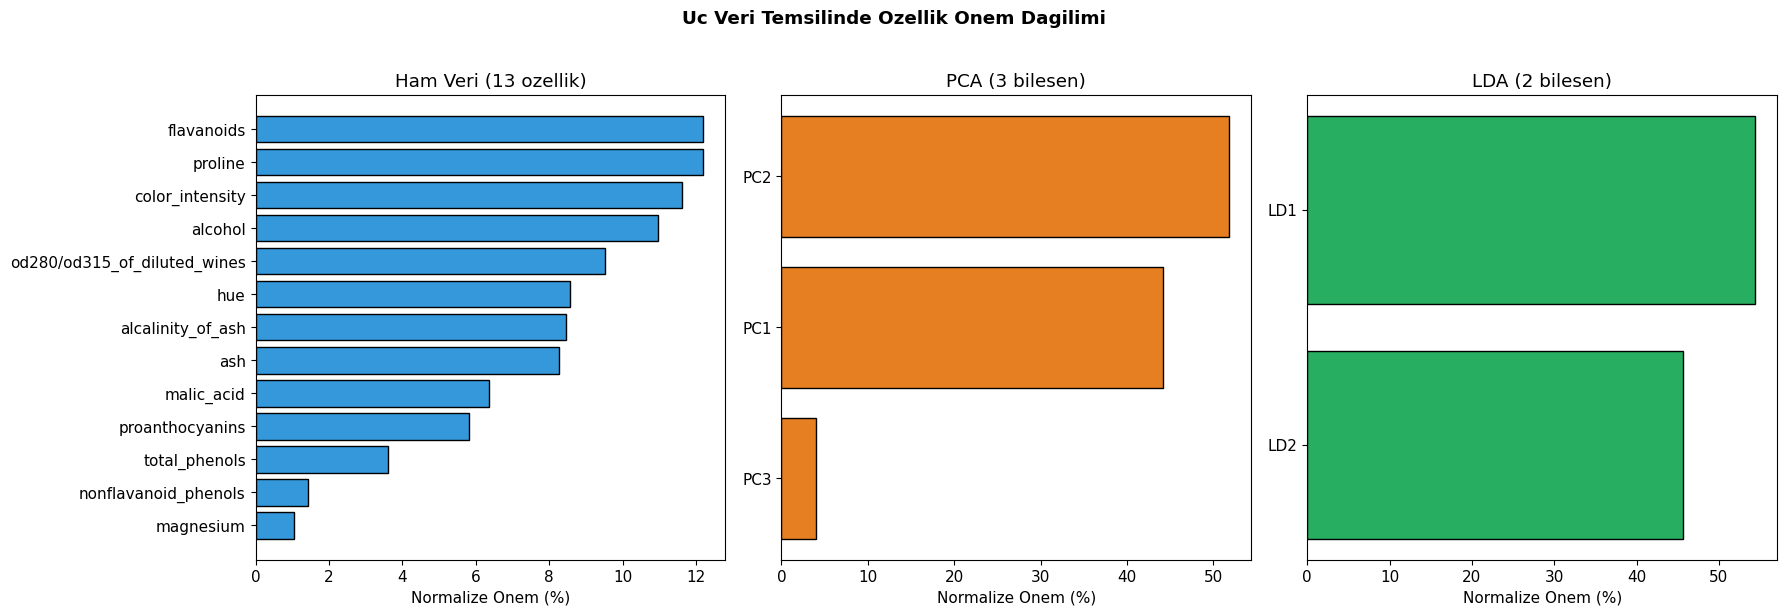

In [38]:
# 10.3.3 Ham / PCA / LDA onem karsilastirmasi
def onem_hesapla(sv, n=3):
    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        return np.mean([np.abs(sv[:,:,c]).mean(axis=0) for c in range(sv.shape[2])], axis=0)
    elif isinstance(sv, list):
        return np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    else:
        return np.abs(sv).mean(axis=0)

onem_ham = onem_hesapla(shap_val)
onem_pca = onem_hesapla(shap_pca)
onem_lda = onem_hesapla(shap_lda)

def normalize(a):
    return a / a.sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ham_df = pd.DataFrame({'isim': X.columns, 'onem': normalize(onem_ham)}).sort_values('onem')
axes[0].barh(ham_df['isim'], ham_df['onem'], color='#3498db', edgecolor='black')
axes[0].set_title(f'Ham Veri ({len(onem_ham)} ozellik)')
axes[0].set_xlabel('Normalize Onem (%)')

pca_labels = [f'PC{i+1}' for i in range(len(onem_pca))]
pca_df = pd.DataFrame({'isim': pca_labels, 'onem': normalize(onem_pca)}).sort_values('onem')
axes[1].barh(pca_df['isim'], pca_df['onem'], color='#e67e22', edgecolor='black')
axes[1].set_title(f'PCA ({len(onem_pca)} bilesen)')
axes[1].set_xlabel('Normalize Onem (%)')

lda_labels = [f'LD{i+1}' for i in range(len(onem_lda))]
lda_df = pd.DataFrame({'isim': lda_labels, 'onem': normalize(onem_lda)}).sort_values('onem')
axes[2].barh(lda_df['isim'], lda_df['onem'], color='#27ae60', edgecolor='black')
axes[2].set_title(f'LDA ({len(onem_lda)} bilesen)')
axes[2].set_xlabel('Normalize Onem (%)')

plt.suptitle('Uc Veri Temsilinde Ozellik Onem Dagilimi', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ham veride onem 13 ozellige yayilmis, LDA'da LD1 neredeyse tum onemi tasiyor

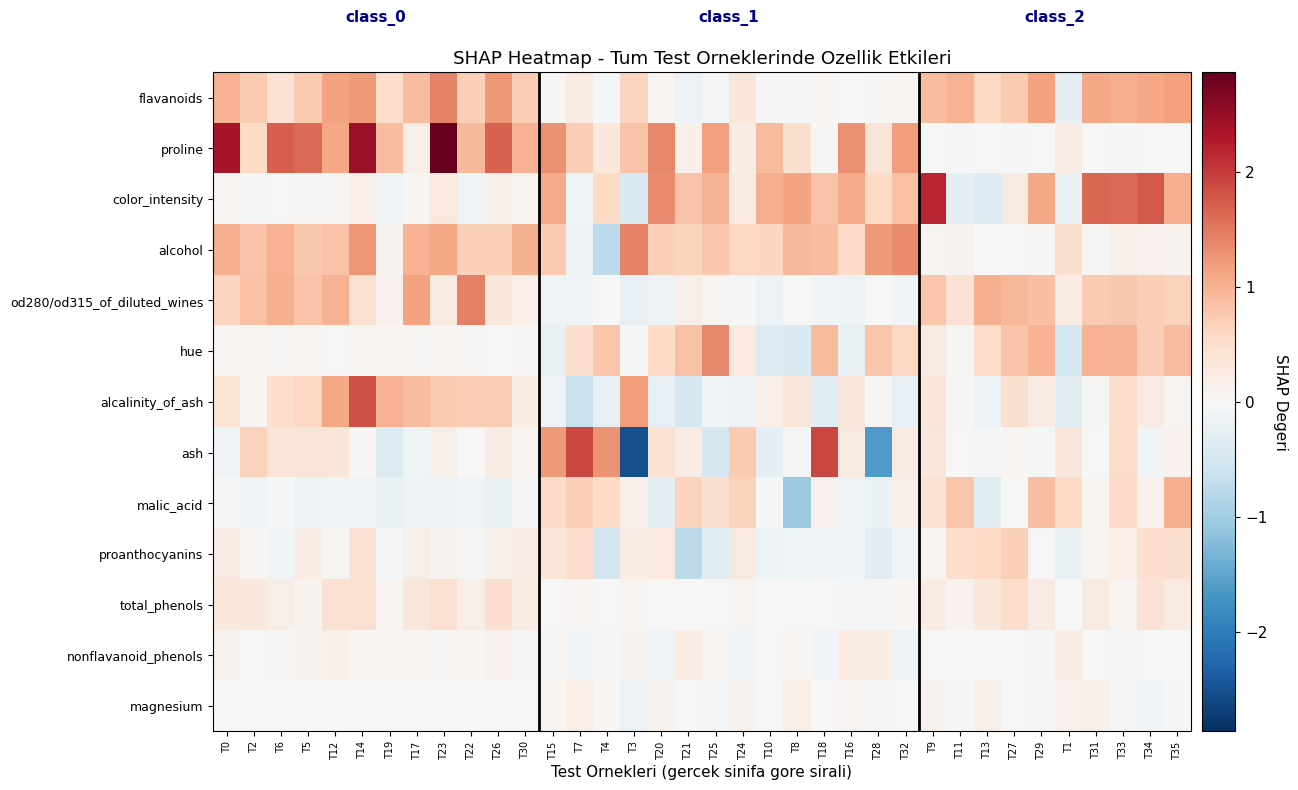

In [39]:
# 10.3.4 SHAP Isi Haritasi - tum test ornekleri
y_pred_all = model.predict(X_test_scaled)
sv_pred    = np.array([sv_list[p][i] for i, p in enumerate(y_pred_all)])

sirali = np.argsort(ort_mutlak)[::-1]
sv_s   = sv_pred[:, sirali]
ozs    = [X.columns[i] for i in sirali]

order  = np.argsort(y_test.values)
sv_hm  = sv_s[order].T

fig, ax = plt.subplots(figsize=(14, 8))
lim = np.max(np.abs(sv_hm))
im  = ax.imshow(sv_hm, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
ax.set_yticks(np.arange(len(ozs)))
ax.set_yticklabels(ozs, fontsize=9)
ax.set_xticks(np.arange(len(y_test)))
ax.set_xticklabels([f'T{i}' for i in np.argsort(y_test.values)], fontsize=7, rotation=90)
ax.set_xlabel('Test Ornekleri (gercek sinifa gore sirali)')
ax.set_title('SHAP Heatmap - Tum Test Orneklerinde Ozellik Etkileri')

y_sorted = y_test.values[order]
sinirlar = np.where(np.diff(y_sorted))[0]
for s in sinirlar:
    ax.axvline(s + 0.5, color='black', linewidth=2)

cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('SHAP Degeri', rotation=270, labelpad=15)

prev = 0
for s in list(sinirlar) + [len(y_sorted)-1]:
    ax.text((prev + s) / 2, -1.5, wine.target_names[y_sorted[prev]],
            ha='center', fontweight='bold', fontsize=11, color='darkblue')
    prev = s + 1

plt.tight_layout()
plt.show()

# class_0 bolgesinde proline/flavanoids kirmizi, class_2 bolgesinde color_intensity kirmizi

---
## Sonuç ve Genel Değerlendirme

### Veri Ön İşleme
- Wine veri seti 178 örnek, 13 sayısal özellik ve 3 sınıftan oluşmaktadır; eksik değer saptanmamıştır.
- IQR yöntemiyle 21, Z-score (|z|>3) yöntemiyle 11 aykırı değer tespit edilmiştir. StandardScaler bu etkileri minimize etmektedir.
- Tüm özellikler float64 tipindedir; kategorik değişken bulunmamaktadır.

### Keşifsel Veri Analizi
- flavanoids–total_phenols (r=0.86) ve od280–flavanoids (r=0.79) en güçlü korelasyonlardır; PCA bu çoklu doğrusallığı giderir.
- Sınıf bazlı boxplot ve histogram analizleri; flavanoids, proline ve color_intensity'nin yüksek diskriminatif güce sahip olduğunu göstermektedir.

### Boyut İndirgeme
- **PCA**: Ortalama explained variance ratio kriteri ile **3 bileşen** seçilmiş; toplam açıklanan varyans %67.2 olmuştur.
- **LDA**: 3 sınıflı veri setinde matematiksel limit **n_classes−1 = 2** bileşendir. LD1 tek başına varyansın %69.3'ünü açıklamaktadır.

### Model Performansı
- 5 algoritma × 3 veri temsili = **15 model** eğitilmiş; validation üzerinde karşılaştırılmıştır.
- LDA temsili ortalama %100 doğruluk sağlamıştır (Ham veri: %98.9, PCA: %96.7).
- En iyi model: **Logistic Regression (Ham Veri)** – Val F1=1.000, Val AUC=1.000.
- Test seti: Accuracy=%97.2, F1=%97.2, ROC-AUC=1.000 (36 örnekten 35'i doğru).

### Threshold Analizi
- Varsayılan eşik (0.5) bu veri seti için optimal F1'ı sağlamaktadır.
- Eşik artırılırsa Precision↑/Recall↓; azaltılırsa Precision↓/Recall↑ tradeoff'u gözlemlenir.

### SHAP Açıklanabilirlik
- Ham veri SHAP analizi en yorumlanabilir sonuçları vermektedir.
- **flavanoids** ve **proline** en etkili özelliklerdir (SHAP ≈ 0.59); EDA gözlemleriyle tamamen tutarlıdır.
- PCA/LDA SHAP: Az sayıda bileşen büyük etki taşırken ham veride etki daha geniş yayılmaktadır.
